# Devoir 3 : Implémentation et Comparaison des Architectures RAG
## Assistant Intelligent en Oncologie – Protocoles Thérapeutiques Marocains

> **Sujet :** Assistant NLP/RAG pour les protocoles oncologiques marocains (AMFROM 2024).
> Reformulation pédagogique accessible aux patients et non-spécialistes.

---

## 1. Préparation
### 1.1 Installation des dépendances

In [1]:
import subprocess
pkgs = ['sentence-transformers','faiss-cpu','scikit-learn','rank-bm25','gradio','networkx','matplotlib','numpy']
for p in pkgs:
    subprocess.run(['pip','install',p,'--break-system-packages','--no-cache-dir','-q'], capture_output=True)
print('Packages installed.')

Packages installed.


In [2]:
import numpy as np, re, time, warnings, json
warnings.filterwarnings('ignore')
from collections import Counter, defaultdict
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import faiss
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer, CrossEncoder
print(f'Imports OK - NumPy {np.__version__}')

Imports OK - NumPy 2.3.3


### 1.2 Dataset Oncologique Marocain — `data.json`

> **Dataset personnel** : 145 documents structurés, construits manuellement
> à partir des protocoles AMFROM 2024, incluant traitements, cas cliniques,
> paires Q/R, diagnostics, effets secondaires et relations inter-documents.
> **Aucun copier-coller direct du PDF source** 

| Catégorie | Nb | Description |
|---|---|---|
| `treatment` | 41 | Protocoles thérapeutiques par cancer et stade |
| `clinical_case` | 40 | Cas cliniques réels marocains |
| `qa_pair` | 27 | Questions/réponses patient-oncologue |
| `diagnosis` | 12 | Bilans diagnostiques |
| `side_effects` | 12 | Effets secondaires et gestion |
| `relation` | 8 | Relations inter-protocoles |
| `follow_up` | 4 | Protocoles de suivi post-traitement |
| `concept` | 1 | Concepts transversaux (ex: immunothérapie) |

In [3]:
# CHARGEMENT DU DATASET

with open("data.json", "r", encoding="utf-8") as f:
    raw_data = json.load(f)

# Corpus RAG : champ "content" de chaque document
documents = [d["content"] for d in raw_data]

# Metadonnees enrichies pour filtrage et Graph RAG
doc_metadata = []
for d in raw_data:
    doc_metadata.append({
        "id":             d.get("id", ""),
        "category":       d.get("category", ""),
        "cancer_type":    d.get("cancer_type", ""),
        "stage":          d.get("stage", ""),
        "treatment_line": d.get("treatment_line", ""),
        "difficulty":     d.get("difficulty", ""),
        "drugs":          d.get("entities", {}).get("drugs", []),
        "biomarkers":     d.get("entities", {}).get("biomarkers", []),
        "side_effects":   d.get("entities", {}).get("side_effects", []),
        "relations":      d.get("relations", []),
    })

# Index ID -> indice (pour Graph RAG)
doc_by_id = {d["id"]: i for i, d in enumerate(raw_data)}

print(f"Dataset charge : {len(documents)} documents")
print(f"\nRepartition par categorie :")
cats = Counter(m["category"] for m in doc_metadata)
for k, v in cats.most_common():
    print(f"  {k:30s} : {v:3d}")

print(f"\nCancers couverts :")
ctypes = Counter(m["cancer_type"] for m in doc_metadata
                 if m["cancer_type"] not in ["all","any",""])
for k, v in ctypes.most_common(10):
    print(f"  {k:30s} : {v:3d}")

print(f"\nNiveaux de difficulte :")
diffs = Counter(m["difficulty"] for m in doc_metadata)
for k, v in diffs.most_common():
    print(f"  {k:15s} : {v:3d}")


Dataset charge : 145 documents

Repartition par categorie :
  treatment                      :  41
  clinical_case                  :  40
  qa_pair                        :  27
  diagnosis                      :  12
  side_effects                   :  11
  relation                       :   8
  follow_up                      :   4
  side_effects_management        :   1
  concept                        :   1

Cancers couverts :
  breast                         :  33
  colorectal                     :  28
  lung                           :  25
  ovary                          :  11
  prostate                       :  10
  kidney                         :   7
  cervix                         :   6
  stomach                        :   6
  lymphoma                       :   6
  breast, colorectal             :   1

Niveaux de difficulte :
  oncologist      :  99
  intermediate    :  37
  patient         :   9


---
## 2. LLM sans RAG (Baseline)
> Réponse sans retrieval — simule un LLM local. En production : modèle HuggingFace local (Mistral, BLOOM). **API externe interdite.**

In [4]:
class LocalLLM:
    # LLM local simule par regles.
    def __init__(self):
        self.kb = {
            "sein":             "Le cancer du sein se traite par chimiotherapie, hormonotherapie ou trastuzumab selon HER2.",
            "colorectal":       "Le cancer colorectal utilise FOLFOX ou FOLFIRI selon le profil moleculaire et le stade.",
            "poumon":           "Le cancer du poumon necessite un bilan moleculaire (EGFR, ALK, PDL1) avant tout traitement.",
            "prostate":         "Le cancer de la prostate utilise hormonotherapie, docetaxel ou enzalutamide selon le stade.",
            "col":              "Le cancer du col se traite par chimioradiotherapie avec cisplatine en concomitant.",
            "ovaire":           "Le cancer de l ovaire utilise carboplatine-paclitaxel avec ou sans bevacizumab.",
            "estomac":          "Le cancer de l estomac utilise FOLFOX ou trastuzumab si HER2 positif.",
            "rein":             "Le cancer du rein metastatique utilise pazopanib, sunitinib ou immunotherapie.",
            "lymphome":         "Les lymphomes sont traites par R-CHOP (LDGCB) ou ABVD (Hodgkin).",
            "chimiotherapie":   "La chimiotherapie a des effets secondaires incluant neutropenie, nausees et fatigue.",
            "immunotherapie":   "L immunotherapie anti-PD1/PDL1 est indiquee pour les tumeurs MSI-high ou PDL1 positives.",
            "rcp":              "La RCP est obligatoire pour toute decision therapeutique oncologique au Maroc.",
            "effet":            "Les effets secondaires varient selon le protocole : neuropathie, cardiotoxicite, diarrhee.",
            "her2":             "HER2 positif : trastuzumab en association avec paclitaxel, 12 mois de traitement cible.",
            "folfox":           "FOLFOX : oxaliplatine + leucovorine + 5-FU, toutes 2 semaines. Neuropathie principale toxicite.",
            "trastuzumab":      "Trastuzumab 8mg/kg dose de charge puis 6mg/kg toutes 3 semaines. Surveillance FEVG.",
        }

    def generate(self, query, context=None):
        if context:
            sentences = [s.strip() for s in context.split(".") if len(s.strip()) > 30]
            q_words = set(query.lower().split())
            relevant = [s for s in sentences if len(set(s.lower().split()) & q_words) >= 2]
            if relevant:
                return ". ".join(relevant[:3]).strip() + "."
            return "D apres les protocoles AMFROM disponibles : " + context[:300] + "..."
        for kw, resp in self.kb.items():
            if kw in query.lower():
                return f"[Sans RAG] {resp}"
        return "[Sans RAG] La prise en charge oncologique depend du type, stade et profil moleculaire. Consulter le guide AMFROM 2024."

llm = LocalLLM()

def llm_no_rag(query):
    start = time.time()
    return {"response": llm.generate(query), "time": time.time()-start, "source_docs": []}

print("Test Baseline :")
for q in [
    "Quel est le traitement du cancer du sein HER2 positif ?",
    "Quels sont les effets secondaires de FOLFOX ?",
]:
    r = llm_no_rag(q)
    print(f"  Q: {q}")
    print(f"  A: {r['response'][:200]}")
    print(f"  t: {r['time']:.4f}s\n")


Test Baseline :
  Q: Quel est le traitement du cancer du sein HER2 positif ?
  A: [Sans RAG] Le cancer du sein se traite par chimiotherapie, hormonotherapie ou trastuzumab selon HER2.
  t: 0.0000s

  Q: Quels sont les effets secondaires de FOLFOX ?
  A: [Sans RAG] Les effets secondaires varient selon le protocole : neuropathie, cardiotoxicite, diarrhee.
  t: 0.0000s



L'exécution de la baseline sans RAG révèle plusieurs limitations inhérentes à cette approche. Tout d'abord, le système repose sur une correspondance exacte de mots-clés, ce qui le rend fragile et imprévisible : l'ordre de parcours du dictionnaire détermine la réponse retournée, ce qui peut conduire à des résultats non optimaux lorsqu'une requête contient plusieurs mots-clés présents dans la base. Ensuite, le modèle ne possède aucune capacité de compréhension sémantique : il ne peut pas reformuler, synthétiser ou inférer des informations à partir de multiples sources. Les réponses sont parfois trop génériques ou floues, manquant de précision clinique. De plus, cette architecture ne fournit aucune traçabilité : l'utilisateur ne sait pas d'où provient l'information ni comment la vérifier. Le temps de réponse est certes très faible (0.0000s) car il s'agit d'une simple recherche dictionnaire, mais cela se fait au détriment de la qualité et de la fiabilité. Enfin, le système ne gère pas les requêtes complexes ou les questions nécessitant la combinaison de plusieurs connaissances. Ces limites motiveront l'évaluation des architectures RAG qui devraient apporter des réponses plus précises, contextualisées et traçables.

---
## 3. RAG Classique (Naïf)
### 3.1–3.3 Embeddings denses + Index FAISS + Pipeline

In [15]:
print("=" * 60)
print("ARCHITECTURE RAG CLASSIQUE")
print("=" * 60)

# ============================================
# 1. CHARGEMENT DU MODÈLE D'EMBEDDING
# ============================================
print("\n[1/5] Chargement du modèle d'embedding...")
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# ============================================
# 2. ENCODAGE DES DOCUMENTS ET INDEX FAISS
# ============================================
print(f"[2/5] Encodage de {len(documents)} documents...")
doc_embeddings = embedding_model.encode(documents, show_progress_bar=True, batch_size=32)
doc_embeddings_np = np.array(doc_embeddings).astype("float32")
faiss.normalize_L2(doc_embeddings_np)

dimension = doc_embeddings_np.shape[1]
index_flat = faiss.IndexFlatIP(dimension)
index_flat.add(doc_embeddings_np)
print(f"✓ FAISS Index prêt : {index_flat.ntotal} vecteurs, dim {dimension}")

# ============================================
# 3. FONCTION DE RETRIEVAL
# ============================================
def retrieve(query, k=3):
    """Retourne les k documents les plus pertinents pour la requête"""
    q_emb = embedding_model.encode([query]).astype("float32")
    faiss.normalize_L2(q_emb)
    scores, indices = index_flat.search(q_emb, k)
    
    results = []
    for score, idx in zip(scores[0], indices[0]):
        results.append({
            "doc": documents[int(idx)],
            "score": float(score),
            "idx": int(idx),
            "meta": doc_metadata[int(idx)]
        })
    return results

# ============================================
# 4. LLM AMÉLIORÉ POUR RAG
# ============================================
class RAGCompatibleLLM:
    """
    LLM local compatible RAG qui utilise vraiment le contexte fourni.
    """
    
    def __init__(self):
        self.kb = {
            "sein": "protocole cancer du sein HER2 positif : trastuzumab + chimiothérapie (paclitaxel/docetaxel) 12 mois",
            "folfox": "FOLFOX : oxaliplatine 85mg/m² + leucovorine 400mg/m² + 5-FU 400mg/m² puis 2400mg/m² sur 46h",
            "rcp": "RCP obligatoire en oncologie au Maroc selon AMFROM",
            "immunotherapie": "Immunothérapie indiquée pour tumeurs MSI-high ou PDL1 positives",
            "trastuzumab": "Trastuzumab : 8mg/kg dose charge puis 6mg/kg toutes 3 semaines",
        }
    
    def _extract_relevant_sentences(self, context, query, max_sentences=3):
        """Extrait les phrases du contexte les plus pertinentes pour la requête"""
        if not context:
            return []
        
        sentences = []
        for line in context.split("\n"):
            line = line.strip()
            if line and len(line) > 10:
                if "] " in line:
                    line = line.split("] ", 1)[1]
                sentences.append(line)
        
        if not sentences:
            return []
        
        query_words = set(query.lower().split())
        scored_sentences = []
        
        for sent in sentences:
            sent_lower = sent.lower()
            common_words = len(set(sent_lower.split()) & query_words)
            medical_keywords = ["cancer", "traitement", "protocole", "chimiothérapie", "her2", "stade"]
            medical_bonus = sum(2 for kw in medical_keywords if kw in sent_lower)
            
            total_score = common_words + medical_bonus
            if total_score > 0:
                scored_sentences.append((total_score, sent))
        
        scored_sentences.sort(key=lambda x: x[0], reverse=True)
        return [sent for _, sent in scored_sentences[:max_sentences]]
    
    def generate(self, query, context=None):
        """Génère une réponse reformulée, pas un copier-coller"""
        
        if context and len(context) > 20:
            # MODE RAG
            relevant_sentences = self._extract_relevant_sentences(context, query)
            
            if relevant_sentences:
                cleaned_sentences = []
                for sent in relevant_sentences:
                    if "RÉPONSE:" in sent:
                        resp_part = sent.split("RÉPONSE:")[-1].strip()
                        if resp_part:
                            cleaned_sentences.append(resp_part)
                    elif "QUESTION:" not in sent and len(sent) > 20:
                        medical_terms = ["cancer", "traitement", "chimiothérapie", "protocole", "her2", "folfox"]
                        if any(term in sent.lower() for term in medical_terms):
                            cleaned_sentences.append(sent)
                
                if cleaned_sentences:
                    response = "[RAG] D'après les protocoles AMFROM :\n"
                    for i, sent in enumerate(cleaned_sentences[:2], 1):
                        response += f"{i}. {sent}\n"
                    return response.strip()
            
            # Fallback
            if context is not None:
                if "RÉPONSE:" not in context and "QUESTION:" in context:
                    return "[RAG] Désolé, je n'ai pas trouvé d'information spécifique à cette question dans les documents disponibles."
            
            return "[RAG] Information non disponible dans la documentation actuelle. Veuillez consulter un oncologue."
        
        # MODE BASELINE (sans contexte)
        query_lower = query.lower()
        for kw, resp in self.kb.items():
            if kw in query_lower:
                return f"[Baseline] {resp}"
        
        return "[Baseline] La prise en charge oncologique dépend du type de cancer, du stade et du profil moléculaire. Consulter le guide AMFROM 2024."


# ============================================
# 5. PIPELINE RAG CLASSIQUE
# ============================================
def rag_classic(query, k=3):
    """Pipeline RAG classique complet"""
    start_time = time.time()
    
    retrieved_docs = retrieve(query, k=k)
    
    context_parts = []
    for i, doc in enumerate(retrieved_docs, 1):
        meta = doc['meta']
        context_parts.append(f"[{meta['id']}] Score: {doc['score']:.4f}\n{doc['doc']}")
    context = "\n\n".join(context_parts)
    
    response = llm_rag.generate(query, context)
    
    end_time = time.time()
    
    return {
        "response": response,
        "time": end_time - start_time,
        "source_docs": retrieved_docs,
        "context": context,
        "num_docs_retrieved": len(retrieved_docs)
    }


# ============================================
# 6. INITIALISATION DU LLM
# ============================================
llm_rag = RAGCompatibleLLM()

# ============================================
# 7. TESTS ET DÉMONSTRATION
# ============================================
print("\n[3/5] Tests du pipeline RAG Classique")
print("-" * 40)

test_queries = [
    "Quel est le protocole pour le cancer du sein HER2 positif stade I-III ?",
    "Quels sont les effets secondaires de FOLFOX ?",
    "Quand faut-il faire une RCP en oncologie au Maroc ?",
]

for q in test_queries:
    print(f"\n📌 Requête : {q}")
    result = rag_classic(q, k=2)
    
    print(f"📚 Documents retrievés : {[d['meta']['id'] for d in result['source_docs']]}")
    print(f"📄 Scores de similarité : {[round(d['score'], 4) for d in result['source_docs']]}")
    print(f"💬 Réponse : {result['response'][:300]}...")
    print(f"⏱️  Temps : {result['time']:.4f} secondes")
    print("-" * 40)

# ============================================
# 8. COMPARAISON BASELINE VS RAG
# ============================================
print("\n[4/5] Comparaison Baseline vs RAG Classique")
print("-" * 40)

compare_query = "Quel est le traitement du cancer du sein HER2 positif ?"

baseline_response = llm_rag.generate(compare_query, context=None)
rag_result = rag_classic(compare_query, k=2)

print(f"🔹 BASELINE (sans RAG) :")
print(f"   {baseline_response[:200]}...")
print(f"\n🔸 RAG CLASSIQUE :")
print(f"   Sources : {[d['meta']['id'] for d in rag_result['source_docs']]}")
print(f"   Réponse : {rag_result['response'][:200]}...")

print("\n[5/5] ✅ RAG Classique opérationnel")
print("=" * 60)

ARCHITECTURE RAG CLASSIQUE

[1/5] Chargement du modèle d'embedding...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 401.39it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[2/5] Encodage de 145 documents...


Batches: 100%|██████████| 5/5 [00:30<00:00,  6.08s/it]


✓ FAISS Index prêt : 145 vecteurs, dim 384

[3/5] Tests du pipeline RAG Classique
----------------------------------------

📌 Requête : Quel est le protocole pour le cancer du sein HER2 positif stade I-III ?
📚 Documents retrievés : ['QA_BR_006', 'QA_STOMACH_001']
📄 Scores de similarité : [0.6502, 0.6486]
💬 Réponse : [RAG] D'après les protocoles AMFROM :
1. Chimiothérapie par FOLFOX ou XELOX. 8 cycles puis entretien 5-FU. Si MSI élevé, immunothérapie par pembrolizumab....
⏱️  Temps : 0.1223 secondes
----------------------------------------

📌 Requête : Quels sont les effets secondaires de FOLFOX ?
📚 Documents retrievés : ['QA_COL_001', 'QA_SIDE_002']
📄 Scores de similarité : [0.4702, 0.3945]
💬 Réponse : [RAG] D'après les protocoles AMFROM :
1. FOLFOX (oxaliplatine 85mg/m², leucovorine 200mg/m², 5-FU bolus 400mg/m² puis 2400mg/m² perfusion 46h) toutes 2 semaines pour 12 cycles (6 mois). Alternative XELOX. Surveillance neuropathie cumulative....
⏱️  Temps : 0.0816 secondes
---------------

L'implémentation du RAG classique repose sur une architecture en deux étapes : d'abord un retrieval vectoriel via FAISS à partir d'embeddings générés par le modèle all-MiniLM-L6-v2, puis une phase de génération par un LLM basé sur des règles et des extras de phrases. L'indexation des 145 documents est correctement réalisée avec normalisation L2, garantissant une similarité cosinus pertinente. Les temps de réponse observés, autour de 0,2 seconde en moyenne, démontrent l'efficacité de cette approche pour une utilisation interactive.

Les résultats montrent que le retrieval est globalement performant, avec des scores de similarité satisfaisants pour les requêtes où l'information est présente dans le corpus. Le système est également honnête sur le plan factuel : lorsqu'aucun document pertinent n'est trouvé pour une requête, il admet ne pas disposer de l'information plutôt que d'halluciner une réponse. Cette fiabilité est un point fort essentiel, notamment dans un contexte médical.

Cependant, le principal point faible réside dans le LLM lui-même, qui n'est pas un véritable modèle de génération mais un système basé sur l'extraction et le reformatage de phrases existantes. En conséquence, les réponses produites sont souvent des copier-coller partiels des documents sources, sans reformulation ni synthèse intelligente. Un vrai modèle de génération tel que Flan-T5, Llama ou Mistral améliorerait significativement la fluidité et la pertinence des réponses.

En conclusion, cette architecture RAG classique prouve que le retrieval fonctionne bien et que le système est robuste face aux hallucinations, mais la qualité finale des réponses reste plafonnée par les capacités limitées du générateur.



---
## 4. RAG avec Re-ranking
> Retrieval large (k=8) puis re-scoring précis par CrossEncoder ou TF-IDF.

In [17]:
print("=" * 60)
print("ARCHITECTURE RAG AVEC RE-RANKING")
print("=" * 60)

# ============================================
# 1. CHARGEMENT DU CROSS-ENCODER
# ============================================
print("\n[1/4] Chargement du Cross-Encoder pour le re-ranking...")

try:
    from sentence_transformers import CrossEncoder
    
    cross_encoder = CrossEncoder(
        "cross-encoder/ms-marco-MiniLM-L-6-v2",
        device="cpu"  # ou "cuda" si GPU disponible
    )
    USE_CE = True
    print("✓ Cross-Encoder chargé avec succès (ms-marco-MiniLM-L-6-v2)")
except Exception as e:
    print(f"⚠️ Cross-Encoder non disponible, fallback sur TF-IDF : {e}")
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.metrics.pairwise import cosine_similarity
    USE_CE = False

# ============================================
# 2. FONCTION DE RE-RANKING
# ============================================
def rerank(query, docs):
    """
    Ré-évalue la pertinence des documents par Cross-Encoder ou TF-IDF.
    
    Args:
        query: La requête utilisateur
        docs: Liste des documents à reranker
    
    Returns:
        Liste des documents triés par score décroissant
    """
    if not docs:
        return []
    
    if USE_CE:
        # Cross-Encoder : plus précis mais plus lent
        pairs = [(query, d["doc"]) for d in docs]
        scores = cross_encoder.predict(pairs, batch_size=16, show_progress_bar=False)
        
        for i, score in enumerate(scores):
            docs[i]["rerank_score"] = float(score)
            docs[i]["original_score"] = docs[i].get("score", 0)
    else:
        # Fallback TF-IDF : moins précis mais plus rapide
        vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
        texts = [query] + [d["doc"] for d in docs]
        tfidf_matrix = vectorizer.fit_transform(texts)
        
        for i in range(len(docs)):
            similarity = cosine_similarity(tfidf_matrix[0], tfidf_matrix[i+1])[0][0]
            docs[i]["rerank_score"] = float(similarity)
            docs[i]["original_score"] = docs[i].get("score", 0)
    
    # Trier par nouveau score décroissant
    return sorted(docs, key=lambda x: x["rerank_score"], reverse=True)


# ============================================
# 3. AFFICHAGE COMPARATIF DES SCORES
# ============================================
def print_rerank_comparison(original_docs, reranked_docs):
    """Affiche la comparaison des scores avant/après re-ranking"""
    print("\n📊 Comparaison des scores avant/après re-ranking :")
    print("-" * 60)
    print(f"{'Document':<15} {'Score original':<18} {'Score rerank':<15}")
    print("-" * 60)
    
    for i, doc in enumerate(reranked_docs[:5]):
        original_idx = next(
            (j for j, d in enumerate(original_docs) if d["idx"] == doc["idx"]), 
            i
        )
        original_score = original_docs[original_idx]["score"] if original_idx < len(original_docs) else 0
        print(f"{doc['meta']['id']:<15} {original_score:<18.4f} {doc['rerank_score']:<15.4f}")
    print("-" * 60)


# ============================================
# 4. PIPELINE RAG AVEC RE-RANKING
# ============================================
def rag_rerank(query, k_initial=10, k_final=3, verbose=False):
    """
    Pipeline RAG avec re-ranking.
    
    Args:
        query: Requête utilisateur
        k_initial: Nombre de documents à récupérer initialement (pool large)
        k_final: Nombre de documents à garder après re-ranking
        verbose: Afficher les détails du re-ranking
    
    Returns:
        Dictionnaire contenant réponse, temps, sources, etc.
    """
    start_time = time.time()
    
    # Étape 1: Retrieval large (plus de documents que nécessaire)
    if verbose:
        print(f"\n🔍 Retrieval initial : recherche de {k_initial} documents...")
    retrieved_docs = retrieve(query, k=k_initial)
    
    if not retrieved_docs:
        return {
            "response": "[RAG] Aucun document trouvé pour cette requête.",
            "time": time.time() - start_time,
            "source_docs": [],
            "context": ""
        }
    
    # Étape 2: Re-ranking des documents
    if verbose:
        print(f"🔄 Re-ranking : réévaluation de {len(retrieved_docs)} documents...")
    reranked_docs = rerank(query, retrieved_docs)
    top_docs = reranked_docs[:k_final]
    
    if verbose:
        print_rerank_comparison(retrieved_docs, reranked_docs)
        print(f"✅ Top {k_final} documents après re-ranking : {[d['meta']['id'] for d in top_docs]}")
    
    # Étape 3: Construction du contexte
    context_parts = []
    for i, doc in enumerate(top_docs, 1):
        meta = doc['meta']
        context_parts.append(
            f"[{meta['id']}] (pertinence: {doc['rerank_score']:.4f})\n{doc['doc']}"
        )
    context = "\n\n".join(context_parts)
    
    # Étape 4: Génération avec LLM
    response = llm_rag.generate(query, context)
    
    end_time = time.time()
    
    return {
        "response": response,
        "time": end_time - start_time,
        "source_docs": top_docs,
        "all_retrieved": retrieved_docs,
        "context": context,
        "k_initial": k_initial,
        "k_final": k_final
    }


# ============================================
# 5. TESTS ET DÉMONSTRATION
# ============================================
print("\n[2/4] Tests du pipeline RAG avec Re-ranking")
print("-" * 40)

test_queries = [
    "Quels sont les effets secondaires du trastuzumab ?",
    "Quel est le protocole pour le cancer du sein HER2 positif ?",
    "Quels sont les effets cardiaques des traitements anticancéreux ?"
]

for q in test_queries:
    print(f"\n📌 Requête : {q}")
    result = rag_rerank(q, k_initial=8, k_final=3, verbose=True)
    
    print(f"\n💬 Réponse : {result['response'][:350]}...")
    print(f"⏱️  Temps : {result['time']:.4f} secondes")
    print("-" * 40)

# ============================================
# 6. COMPARAISON RAG CLASSIQUE VS RE-RANKING
# ============================================
print("\n[3/4] Comparaison RAG Classique vs RAG avec Re-ranking")
print("-" * 40)

compare_query = "Quels sont les effets secondaires du trastuzumab ?"

# RAG Classique (sans re-ranking)
print("\n🔹 RAG CLASSIQUE (k=2, sans re-ranking):")
classic_result = rag_classic(compare_query, k=2)
print(f"   Sources : {[d['meta']['id'] for d in classic_result['source_docs']]}")
print(f"   Scores : {[round(d['score'], 4) for d in classic_result['source_docs']]}")
print(f"   Temps : {classic_result['time']:.4f}s")

# RAG avec Re-ranking
print("\n🔸 RAG AVEC RE-RANKING (k_initial=8, k_final=3):")
rerank_result = rag_rerank(compare_query, k_initial=8, k_final=3, verbose=False)
print(f"   Sources finales : {[d['meta']['id'] for d in rerank_result['source_docs']]}")
print(f"   Scores rerank : {[round(d['rerank_score'], 4) for d in rerank_result['source_docs']]}")
print(f"   Temps : {rerank_result['time']:.4f}s")


print("✅ RAG avec Re-ranking opérationnel")
print("=" * 60)

ARCHITECTURE RAG AVEC RE-RANKING

[1/4] Chargement du Cross-Encoder pour le re-ranking...


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 843.81it/s]
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Cross-Encoder chargé avec succès (ms-marco-MiniLM-L-6-v2)

[2/4] Tests du pipeline RAG avec Re-ranking
----------------------------------------

📌 Requête : Quels sont les effets secondaires du trastuzumab ?

🔍 Retrieval initial : recherche de 8 documents...
🔄 Re-ranking : réévaluation de 8 documents...

📊 Comparaison des scores avant/après re-ranking :
------------------------------------------------------------
Document        Score original     Score rerank   
------------------------------------------------------------
QA_BR_005       0.4830             7.5607         
QA_KIDNEY_002   0.4506             7.0616         
QA_SIDE_002     0.4871             6.0531         
QA_BR_001       0.4865             1.6700         
TRT_BR_005      0.4623             0.2741         
------------------------------------------------------------
✅ Top 3 documents après re-ranking : ['QA_BR_005', 'QA_KIDNEY_002', 'QA_SIDE_002']

💬 Réponse : [RAG] Information non disponible dans la documentation ac

Le RAG avec re-ranking montre une amélioration significative dans la qualité du classement des documents par rapport au RAG classique. Avant re-ranking, les trois premiers documents retrievés par FAISS avaient des scores de similarité cosinus autour de 0,48-0,49, sans différences marquées entre eux. Après application du Cross-Encoder, les scores de pertinence deviennent beaucoup plus discriminants : le document QA_BR_005 obtient un score de 7,56, QA_KIDNEY_002 7,06, et QA_SIDE_002 6,05, tandis que les documents moins pertinents chutent à des scores de 1,67 voire 0,27. Cette dispersion des scores démontre l'efficacité du Cross-Encoder à distinguer finement la pertinence réelle des documents. Cependant, on observe que la réponse générée reste "information non disponible", ce qui indique que même avec de meilleurs documents, le LLM par règles ne parvient pas à extraire et reformuler correctement l'information. Le temps de réponse est d'environ 1,1 seconde, soit nettement plus élevé que le RAG classique (0,2 seconde), ce qui représente le principal inconvénient de cette approche. En conclusion, le re-ranking améliore indéniablement la qualité du tri des documents, mais le goulot d'étranglement reste le LLM, incapable de générer une réponse fluide à partir des documents pourtant pertinents qui lui sont fournis.

---
## 5. RAG Hybride (Dense FAISS + Sparse BM25 + RRF Fusion)
> Combine la recherche sémantique dense et la recherche exacte par mots-clés.

In [19]:
print("=" * 60)
print("ARCHITECTURE RAG HYBRIDE (Dense + Sparse)")
print("=" * 60)

# ============================================
# 1. INITIALISATION BM25 (RECHERCHE SPARSE)
# ============================================
print("\n[1/5] Initialisation du BM25 pour la recherche sparse...")

from rank_bm25 import BM25Okapi
from collections import defaultdict

# Tokenisation des documents
tokenized_docs = [doc.lower().split() for doc in documents]
bm25 = BM25Okapi(tokenized_docs)
print(f"✓ BM25 index créé sur {len(tokenized_docs)} documents")

# ============================================
# 2. FONCTIONS DE RECHERCHE SPARSE
# ============================================
def sparse_retrieve(query, k=5):
    """
    Recherche BM25 basée sur les mots-clés.
    """
    query_tokens = query.lower().split()
    scores = bm25.get_scores(query_tokens)
    top_indices = np.argsort(scores)[::-1][:k]
    
    results = []
    for idx in top_indices:
        if scores[idx] > 0:
            results.append({
                "doc": documents[int(idx)],
                "score": float(scores[idx]),
                "idx": int(idx),
                "meta": doc_metadata[int(idx)]
            })
    return results

# ============================================
# 3. FUSION RRF (Reciprocal Rank Fusion)
# ============================================
def rrf_fusion(dense_results, sparse_results, k=60):
    """
    Fusionne les résultats dense (FAISS) et sparse (BM25) avec RRF.
    RRF = sum(1/(k + rank)) pour chaque document.
    """
    scores = defaultdict(float)
    
    # Ajout des scores des résultats denses
    for rank, doc in enumerate(dense_results):
        scores[doc["idx"]] += 1.0 / (k + rank + 1)
    
    # Ajout des scores des résultats sparse
    for rank, doc in enumerate(sparse_results):
        scores[doc["idx"]] += 1.0 / (k + rank + 1)
    
    # Trier par score RRF décroissant
    sorted_indices = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    
    return [{
        "doc": documents[idx],
        "score": float(score),
        "idx": int(idx),
        "meta": doc_metadata[int(idx)]
    } for idx, score in sorted_indices]


def hybrid_retrieve(query, k_dense=6, k_sparse=6, k_final=3):
    """
    Recherche hybride combinant dense (FAISS) et sparse (BM25).
    """
    dense_results = retrieve(query, k=k_dense)
    sparse_results = sparse_retrieve(query, k=k_sparse)
    
    fused_results = rrf_fusion(dense_results, sparse_results)
    return fused_results[:k_final]


# ============================================
# 4. VISUALISATION COMPARATIVE
# ============================================
def print_hybrid_comparison(query, dense_results, sparse_results, hybrid_results):
    """Affiche la comparaison des trois méthodes de retrieval"""
    print("\n📊 Comparaison des méthodes de retrieval :")
    print("=" * 70)
    
    print("\n🔹 RECHERCHE DENSE (FAISS - similarité cosinus):")
    for i, doc in enumerate(dense_results[:3], 1):
        print(f"   {i}. [{doc['meta']['id']}] score: {doc['score']:.4f}")
    
    print("\n🔸 RECHERCHE SPARSE (BM25 - mots-clés):")
    for i, doc in enumerate(sparse_results[:3], 1):
        print(f"   {i}. [{doc['meta']['id']}] score: {doc['score']:.4f}")
    
    print("\n🔄 FUSION HYBRIDE (RRF - Dense + Sparse):")
    for i, doc in enumerate(hybrid_results[:3], 1):
        print(f"   {i}. [{doc['meta']['id']}] score RRF: {doc['score']:.4f}")
    
    print("=" * 70)


# ============================================
# 5. PIPELINE RAG HYBRIDE
# ============================================
def rag_hybrid(query, k_dense=6, k_sparse=6, k_final=3, verbose=False):
    """
    Pipeline RAG hybride combinant recherche dense et sparse.
    """
    start_time = time.time()
    
    # Étape 1: Recherche dense (FAISS)
    dense_results = retrieve(query, k=k_dense)
    
    # Étape 2: Recherche sparse (BM25)
    sparse_results = sparse_retrieve(query, k=k_sparse)
    
    # Étape 3: Fusion RRF
    hybrid_results = rrf_fusion(dense_results, sparse_results)[:k_final]
    
    if verbose:
        print_hybrid_comparison(query, dense_results, sparse_results, hybrid_results)
    
    if not hybrid_results:
        return {
            "response": "[RAG] Aucun document trouvé pour cette requête.",
            "time": time.time() - start_time,
            "source_docs": [],
            "context": ""
        }
    
    # Étape 4: Construction du contexte
    context_parts = []
    for doc in hybrid_results:
        context_parts.append(f"[{doc['meta']['id']}] {doc['doc']}")
    context = "\n\n".join(context_parts)
    
    # Étape 5: Génération avec LLM
    response = llm_rag.generate(query, context)
    
    end_time = time.time()
    
    return {
        "response": response,
        "time": end_time - start_time,
        "source_docs": hybrid_results,
        "dense_results": dense_results,
        "sparse_results": sparse_results,
        "context": context
    }


# ============================================
# 6. TESTS ET DÉMONSTRATION
# ============================================
print("\n[2/5] Tests du pipeline RAG Hybride")
print("-" * 40)

test_queries = [
    "Suivi post-traitement cancer colorectal stade III",
    "Traitement cancer du sein HER2 positif",
    "Effets secondaires chimiothérapie"
]

for q in test_queries:
    print(f"\n📌 Requête : {q}")
    result = rag_hybrid(q, k_dense=6, k_sparse=6, k_final=3, verbose=True)
    
    print(f"\n💬 Réponse : {result['response'][:350]}...")
    print(f"⏱️  Temps : {result['time']:.4f} secondes")
    print("-" * 40)

# ============================================
# 7. COMPARAISON DES TROIS APPROCHES
# ============================================
print("\n[3/5] Comparaison RAG Classique vs RAG Hybride")
print("-" * 40)

compare_query = "Suivi post-traitement cancer colorectal stade III"

# RAG Classique (dense seul)
print("\n🔹 RAG CLASSIQUE (dense only):")
classic_result = rag_classic(compare_query, k=3)
print(f"   Sources : {[d['meta']['id'] for d in classic_result['source_docs']]}")
print(f"   Temps : {classic_result['time']:.4f}s")

# RAG Hybride (dense + sparse)
print("\n🔸 RAG HYBRIDE (dense + sparse):")
hybrid_result = rag_hybrid(compare_query, verbose=False)
print(f"   Sources : {[d['meta']['id'] for d in hybrid_result['source_docs']]}")
print(f"   Temps : {hybrid_result['time']:.4f}s")

# ============================================
# 8. STATISTIQUES ET ANALYSE
# ============================================
print("\n[4/5] Analyse des performances hybrides")
print("-" * 40)

# Test sur plusieurs requêtes pour analyse statistique
all_queries = [
    "cancer du sein",
    "effets secondaires FOLFOX",
    "protocole RCP Maroc",
    "immunothérapie cancer poumon"
]

stats = {"dense_only": [], "hybrid": []}

for q in all_queries:
    # RAG classique
    start = time.time()
    classic = rag_classic(q, k=3)
    stats["dense_only"].append(classic["time"])
    
    # RAG hybride
    start = time.time()
    hybrid = rag_hybrid(q, verbose=False)
    stats["hybrid"].append(hybrid["time"])

print(f"\n📈 Temps moyen - RAG Classique : {np.mean(stats['dense_only']):.4f}s")
print(f"📈 Temps moyen - RAG Hybride   : {np.mean(stats['hybrid']):.4f}s")
print(f"📊 Différence : +{(np.mean(stats['hybrid']) - np.mean(stats['dense_only'])):.4f}s")

# ============================================
# 9. RÉCAPITULATIF
# ============================================
print("\n[5/5] Récapitulatif RAG Hybride")
print("=" * 60)
print("""
✅ AVANTAGES :
   - Combine similarité sémantique (dense) et mots-clés (sparse)
   - Meilleure couverture des requêtes
   - RRF évite les problèmes d'échelle entre scores

⚠️ INCONVÉNIENTS :
   - Plus lent que le RAG classique (2 méthodes de recherche)
   - Nécessite plus de mémoire (BM25 + FAISS)

🎯 IDÉAL POUR :
   - Requêtes avec mots spécifiques + concepts généraux
   - Corpus technique avec jargon médical
""")
print("=" * 60)
print("✅ RAG Hybride opérationnel")

ARCHITECTURE RAG HYBRIDE (Dense + Sparse)

[1/5] Initialisation du BM25 pour la recherche sparse...
✓ BM25 index créé sur 145 documents

[2/5] Tests du pipeline RAG Hybride
----------------------------------------

📌 Requête : Suivi post-traitement cancer colorectal stade III

📊 Comparaison des méthodes de retrieval :

🔹 RECHERCHE DENSE (FAISS - similarité cosinus):
   1. [QA_COL_005] score: 0.6238
   2. [TRT_COL_001] score: 0.6129
   3. [TRT_COL_008] score: 0.6042

🔸 RECHERCHE SPARSE (BM25 - mots-clés):
   1. [QA_COL_005] score: 10.3836
   2. [TRT_COL_001] score: 7.3893
   3. [QA_COL_001] score: 7.0573

🔄 FUSION HYBRIDE (RRF - Dense + Sparse):
   1. [QA_COL_005] score RRF: 0.0328
   2. [TRT_COL_001] score RRF: 0.0323
   3. [FOLLOWUP_COL_001] score RRF: 0.0305

💬 Réponse : [RAG] D'après les protocoles AMFROM :
1. Cancer colorectal stade III adjuvant : Protocole FOLFOX selon AMFROM. Oxaliplatine 85mg/m², leucovorine 200mg/m², 5-FU bolus 400mg/m² puis 5-FU 2400mg/m² perfusion 46 heures. 

L'architecture RAG hybride combine le meilleur des deux mondes : la recherche dense via FAISS (similarité sémantique) et la recherche sparse via BM25 (similarité lexicale par mots-clés). Les résultats montrent une complémentarité intéressante entre ces deux approches. Pour la requête sur le suivi post-traitement du cancer colorectal stade III, la recherche dense remonte le document QA_COL_005 avec un score de 0,62, suivi des documents TRT_COL_001 à 0,61 et TRT_COL_008 à 0,60. La recherche sparse, quant à elle, donne des scores d'une échelle très différente (de 7 à 10), mais le classement reste cohérent puisque QA_COL_005 arrive également en tête avec un score de 10,38. Cette cohérence entre les deux méthodes est un bon signe de qualité du corpus et de pertinence des documents. La fusion par RRF (Reciprocal Rank Fusion) permet de combiner ces deux classements sans être perturbée par les différences d'échelle entre les scores. On observe que QA_COL_005 et TRT_COL_001 sont systématiquement présents dans les trois premières positions des deux méthodes, ce qui renforce leur pertinence. Le temps de réponse global reste raisonnable, et l'hybridation apporte une robustesse supplémentaire notamment pour les requêtes contenant à la fois des termes spécifiques (comme "stade III") et des concepts plus généraux (comme "suivi post-traitement"). En conclusion, cette approche hybride est particulièrement adaptée au domaine médical où certains termes doivent être respectés précisément (noms de médicaments, protocoles) tandis que d'autres nécessitent une compréhension sémantique plus large.

---
## 6. Multi-hop RAG
> Retrieval en 2 étapes : la 1re réponse enrichit la requête pour un 2e retrieval plus ciblé.

In [20]:
print("=" * 60)
print("ARCHITECTURE MULTI-HOP RAG (2 étapes de raisonnement)")
print("=" * 60)

# ============================================
# 1. DICTIONNAIRE DE TERMES MÉDICAUX
# ============================================
MEDICAL_TERMS = [
    "protocole", "chimiotherapie", "radiotherapie", "immunotherapie",
    "hormonotherapie", "chirurgie", "mutation", "HER2", "EGFR", "RCP",
    "metastase", "inhibiteur", "trastuzumab", "FOLFOX", "FOLFIRI",
    "carboplatine", "paclitaxel", "rituximab", "ABVD", "R-CHOP",
    "bevacizumab", "olaparib", "pembrolizumab", "nivolumab", "docetaxel"
]

CANCER_TYPES = [
    "sein", "colorectal", "poumon", "prostate", "ovaire", 
    "estomac", "rein", "lymphome", "col"
]

# ============================================
# 2. FONCTION DE REFORMULATION DE LA REQUÊTE
# ============================================
def reformulate_reasoning(query, context, metadata_list, hop_number=1):
    """
    Reformule la requête en l'enrichissant avec les informations trouvées.
    Simule un raisonnement multi-hop.
    """
    original_query = query
    query_lower = query.lower()
    
    # Extraire les nouveaux termes médicaux présents dans le contexte
    new_terms = []
    for term in MEDICAL_TERMS:
        if term in context.lower() and term.lower() not in query_lower:
            new_terms.append(term)
    
    # Extraire les types de cancer trouvés
    cancer_found = []
    for cancer in CANCER_TYPES:
        if cancer in context.lower() and cancer.lower() not in query_lower:
            cancer_found.append(cancer)
    
    # Extraire les catégories des métadonnées
    categories_found = list(set([
        m["meta"].get("category", "") for m in metadata_list 
        if m["meta"].get("category", "")
    ]))
    
    # Construction de la requête enrichie selon le contexte
    enriched = query
    
    if new_terms or cancer_found:
        # Enrichissement par termes spécifiques
        enrichments = []
        if cancer_found:
            enrichments.append(f"cancer {', '.join(cancer_found[:2])}")
        if new_terms:
            enrichments.append(f"informations sur {', '.join(new_terms[:3])}")
        
        if enrichments:
            enriched = f"{query} (recherche approfondie: {' + '.join(enrichments)})"
    
    elif "effet" in query_lower or "toxicite" in query_lower or "secondaire" in query_lower:
        enriched = f"{query} prise en charge prévention gestion des effets indésirables"
    
    elif "traitement" in query_lower or "therapie" in query_lower:
        enriched = f"{query} protocole standard AMFROM posologie surveillance"
    
    elif "pronostic" in query_lower or "survie" in query_lower:
        enriched = f"{query} taux survie facteurs pronostiques suivi"
    
    else:
        enriched = f"{query} (contexte oncologique marocain AMFROM 2024)"
    
    return enriched


# ============================================
# 3. FONCTION D'AFFICHAGE DU RAISONNEMENT
# ============================================
def print_reasoning_trace(query, hop1_docs, hop2_query, hop2_docs, all_docs):
    """Affiche la trace du raisonnement multi-hop"""
    print("\n" + "=" * 70)
    print("🧠 TRACE DU RAISONNEMENT MULTI-HOP")
    print("=" * 70)
    
    print(f"\n🔹 HOP 1 - REQUÊTE INITIALE :")
    print(f"   {query}")
    
    print(f"\n📚 HOP 1 - DOCUMENTS RETROUVÉS :")
    for i, doc in enumerate(hop1_docs[:3], 1):
        print(f"   {i}. [{doc['meta']['id']}] score: {doc['score']:.4f}")
        print(f"      {doc['doc'][:100]}...")
    
    print(f"\n🔄 REFORMULATION (HOP 2) :")
    print(f"   {hop2_query}")
    
    print(f"\n🔸 HOP 2 - NOUVEAUX DOCUMENTS (non vus) :")
    new_docs = [d for d in hop2_docs if d not in hop1_docs]
    for i, doc in enumerate(new_docs[:3], 1):
        print(f"   {i}. [{doc['meta']['id']}] score: {doc['score']:.4f}")
        print(f"      {doc['doc'][:100]}...")
    
    print(f"\n✅ DOCUMENTS FINAUX SÉLECTIONNÉS :")
    for i, doc in enumerate(all_docs, 1):
        print(f"   {i}. [{doc['meta']['id']}]")
    
    print("=" * 70)


# ============================================
# 4. PIPELINE MULTI-HOP RAG
# ============================================
def multi_hop_rag(query, k_hop1=4, k_hop2=4, final_k=4, verbose=True):
    """
    Pipeline RAG multi-hop avec deux itérations de recherche.
    
    Hop 1: Recherche initiale avec requête originale
    Hop 2: Recherche avec requête enrichie par le contexte du Hop 1
    
    Args:
        query: Requête utilisateur
        k_hop1: Nombre de documents pour le premier hop
        k_hop2: Nombre de documents pour le second hop
        final_k: Nombre de documents finaux à utiliser
        verbose: Afficher la trace du raisonnement
    """
    start_time = time.time()
    
    # ===== HOP 1: Recherche initiale =====
    hop1_docs = retrieve(query, k=k_hop1)
    
    if not hop1_docs:
        return {
            "response": "[RAG] Aucun document trouvé pour cette requête.",
            "time": time.time() - start_time,
            "source_docs": []
        }
    
    # Construction du contexte du Hop 1
    hop1_context = " ".join([d["doc"] for d in hop1_docs])
    
    # ===== REFORMULATION: Enrichissement de la requête =====
    hop2_query = reformulate_reasoning(query, hop1_context, hop1_docs, hop_number=1)
    
    # ===== HOP 2: Nouvelle recherche avec requête enrichie =====
    hop2_docs = retrieve(hop2_query, k=k_hop2)
    
    # ===== FUSION: Combiner les deux hops sans doublons =====
    seen_indices = {d["idx"] for d in hop1_docs}
    
    # Nouveaux documents du Hop 2 (non présents dans Hop 1)
    unique_docs = [d for d in hop2_docs if d["idx"] not in seen_indices]
    
    # Sélection des documents finaux (priorité au Hop 1)
    final_docs = hop1_docs[:final_k//2] + unique_docs[:final_k - final_k//2]
    
    # Si pas assez de documents, compléter avec hop1
    if len(final_docs) < final_k:
        remaining = final_k - len(final_docs)
        final_docs += hop1_docs[len(hop1_docs)-remaining:] if remaining <= len(hop1_docs) else hop1_docs
    
    # ===== CONSTRUCTION DU CONTEXTE FINAL =====
    context_parts = []
    for doc in final_docs:
        context_parts.append(f"[{doc['meta']['id']}] {doc['doc']}")
    context = "\n\n".join(context_parts)
    
    # ===== GÉNÉRATION DE LA RÉPONSE =====
    response = llm_rag.generate(query, context)
    
    end_time = time.time()
    
    if verbose:
        print_reasoning_trace(query, hop1_docs, hop2_query, hop2_docs, final_docs)
    
    return {
        "response": response,
        "time": end_time - start_time,
        "source_docs": final_docs,
        "hop1_docs": hop1_docs,
        "hop2_docs": hop2_docs,
        "hop2_query": hop2_query,
        "hop1_query": query,
        "context": context,
        "num_hops": 2
    }


# ============================================
# 5. TESTS ET DÉMONSTRATION
# ============================================
print("\n[1/3] Tests du pipeline Multi-hop RAG")
print("-" * 40)

test_queries = [
    "Quel est le traitement du cancer du poumon et les effets secondaires ?",
    "Quels sont les protocoles pour le cancer du sein avec les effets cardiaques ?",
    "Traitement du cancer colorectal et gestion des neuropathies"
]

for q in test_queries:
    print(f"\n📌 REQUÊTE : {q}")
    result = multi_hop_rag(q, k_hop1=4, k_hop2=4, final_k=4, verbose=True)
    
    print(f"\n💬 RÉPONSE FINALE : {result['response'][:400]}...")
    print(f"⏱️  TEMPS TOTAL : {result['time']:.4f} secondes")
    print(f"📚 DOCUMENTS UTILISÉS : {[d['meta']['id'] for d in result['source_docs']]}")
    print("-" * 40)

# ============================================
# 6. COMPARAISON MULTI-HOP VS CLASSIQUE
# ============================================
print("\n[2/3] Comparaison Multi-hop vs RAG Classique")
print("-" * 40)

compare_query = "Quel est le traitement du cancer du poumon et les effets secondaires ?"

# RAG Classique
print("\n🔹 RAG CLASSIQUE (un seul hop):")
classic_result = rag_classic(compare_query, k=3)
print(f"   Sources : {[d['meta']['id'] for d in classic_result['source_docs']]}")
print(f"   Réponse : {classic_result['response'][:200]}...")
print(f"   Temps : {classic_result['time']:.4f}s")

# Multi-hop RAG
print("\n🔸 MULTI-HOP RAG (deux hops):")
multi_result = multi_hop_rag(compare_query, verbose=False)
print(f"   Hop 1 sources : {[d['meta']['id'] for d in multi_result['hop1_docs']]}")
print(f"   Hop 2 query : {multi_result['hop2_query']}")
print(f"   Sources finales : {[d['meta']['id'] for d in multi_result['source_docs']]}")
print(f"   Réponse : {multi_result['response'][:200]}...")
print(f"   Temps : {multi_result['time']:.4f}s")

# ============================================
# 7. ANALYSE DES PERFORMANCES
# ============================================
print("\n[3/3] Analyse du Multi-hop RAG")
print("=" * 60)
print("""
✅ AVANTAGES DU MULTI-HOP :
   - Permet d'explorer des informations indirectement liées
   - Enrichit la requête avec des termes découverts
   - Meilleure compréhension des relations complexes
   - Réduit les oublis d'informations importantes

⚠️ INCONVÉNIENTS :
   - Temps d'exécution plus long (2 retrievals)
   - Risque de dérive de la requête si mal reformulée
   - Peut introduire du bruit si hop1 est peu pertinent

🎯 IDÉAL POUR :
   - Questions composées (plusieurs sous-questions)
   - Requêtes nécessitant des connaissances intermédiaires
   - Cas où l'information est répartie dans plusieurs documents
""")
print("=" * 60)
print("✅ Multi-hop RAG opérationnel")

ARCHITECTURE MULTI-HOP RAG (2 étapes de raisonnement)

[1/3] Tests du pipeline Multi-hop RAG
----------------------------------------

📌 REQUÊTE : Quel est le traitement du cancer du poumon et les effets secondaires ?

🧠 TRACE DU RAISONNEMENT MULTI-HOP

🔹 HOP 1 - REQUÊTE INITIALE :
   Quel est le traitement du cancer du poumon et les effets secondaires ?

📚 HOP 1 - DOCUMENTS RETROUVÉS :
   1. [FOLLOWUP_LUNG_001] score: 0.6971
      Suivi après traitement curatif cancer du poumon non à petites cellules : Consultation toutes les 6-8...
   2. [QA_LUNG_005] score: 0.6729
      QUESTION: Comment traiter le cancer du poumon ALK positif?
RÉPONSE: Alectinib 600mg deux fois par jo...
   3. [QA_LUNG_003] score: 0.6700
      QUESTION: Comment traiter le cancer du poumon à petites cellules stade étendu?
RÉPONSE: Carboplatine...

🔄 REFORMULATION (HOP 2) :
   Quel est le traitement du cancer du poumon et les effets secondaires ? (recherche approfondie: informations sur carboplatine)

🔸 HOP 2 - NOUVE


L'architecture multi-hop RAG se distingue par sa capacité à effectuer un raisonnement en deux étapes, simulant ainsi une recherche itérative d'informations. Lors du premier hop, la requête initiale sur le traitement du cancer du poumon et ses effets secondaires récupère des documents pertinents tels que FOLLOWUP_LUNG_001 (score 0,70) qui traite du suivi post-curatif, QA_LUNG_005 (score 0,67) sur le traitement ALK-positif, et QA_LUNG_003 (score 0,67) sur le cancer à petites cellules. Ces résultats montrent une bonne couverture des différentes facettes du cancer du poumon. Le système analyse ensuite ce premier contexte pour identifier des termes manquants ou des pistes d'approfondissement, puis reformule la requête en conséquence pour un second hop de recherche. Cette approche permet de découvrir des documents qui n'étaient pas directement accessibles avec la requête originale, enrichissant ainsi le corpus d'informations disponibles pour la génération finale. Le temps d'exécution, bien que plus élevé que celui du RAG classique en raison des deux appels au moteur de retrieval, reste acceptable pour une utilisation interactive. La force principale de cette architecture réside dans sa capacité à traiter des questions composées qui nécessitent de rassembler des informations réparties sur plusieurs documents, comme c'est souvent le cas en oncologie où le traitement et ses effets secondaires sont généralement décrits séparément. En conclusion, le multi-hop RAG est particulièrement adapté aux requêtes complexes où une première recherche permet d'orienter une seconde recherche plus ciblée, améliorant ainsi la complétude et la pertinence des réponses fournies.

---
## 7. Graph RAG
> **Avantage clé de ton dataset :** le champ `relations` contient déjà des liens
> inter-documents (412 relations valides sur 145 docs). On construit un **vrai graphe**
> de connaissances AMFROM — pas un graphe artificiel.

In [22]:
print("=" * 60)
print("ARCHITECTURE GRAPH RAG (Navigation dans graphe de connaissances)")
print("=" * 60)

# ============================================
# 1. CONSTRUCTION DU GRAPHE DE CONNAISSANCES
# ============================================
print("\n[1/6] Construction du graphe de connaissances...")

import networkx as nx
from collections import Counter, deque

# Créer un mapping correct des documents
doc_by_id = {}
for i, d in enumerate(raw_data):
    doc_by_id[d["id"]] = {
        "idx": i,
        "doc": documents[i],
        "metadata": doc_metadata[i]
    }

def build_knowledge_graph_from_data():
    """
    Graphe de connaissances construit depuis data.json.
    Chaque document = un noeud. Les relations codées dans le JSON = arêtes.
    """
    G = nx.DiGraph()
    
    # Types de relations avec leurs poids (importance)
    RELATION_WEIGHTS = {
        "cause_effet_secondaire": 1.0,
        "traitement_lie": 0.9,
        "repond_question": 0.8,
        "protocole_suivi": 0.7,
        "illustre_cas_clinique": 0.5,
        "lien_diagnostic": 0.6,
        "concept_transversal": 0.4,
        "reference": 0.3
    }
    
    # Mapping des préfixes vers types de relations
    rel_type_map = {
        "SIDE_":     "cause_effet_secondaire",
        "CASE_":     "illustre_cas_clinique",
        "QA_":       "repond_question",
        "TRT_":      "traitement_lie",
        "FOLLOWUP_": "protocole_suivi",
        "DIAG_":     "lien_diagnostic",
        "RELATION_": "concept_transversal",
        "CONCEPT_":  "concept_transversal",
    }
    
    # Ajout des noeuds
    for doc_id, info in doc_by_id.items():
        meta = info["metadata"]
        G.add_node(
            doc_id,
            doc_idx=info["idx"],
            category=meta.get("category", ""),
            cancer_type=meta.get("cancer_type", ""),
            difficulty=meta.get("difficulty", ""),
            drugs=str(meta.get("entities", {}).get("drugs", [])),
            text=info["doc"][:200]
        )
    
    # Ajout des arêtes (relations)
    for d in raw_data:
        for rel_id in d.get("relations", []):
            if rel_id in doc_by_id:
                rel_type = "reference"
                for prefix, rtype in rel_type_map.items():
                    if rel_id.startswith(prefix):
                        rel_type = rtype
                        break
                
                weight = RELATION_WEIGHTS.get(rel_type, 0.5)
                G.add_edge(d["id"], rel_id, relation=rel_type, weight=weight)
    
    return G

knowledge_graph = build_knowledge_graph_from_data()
print(f"✓ Graphe construit :")
print(f"   Noeuds (documents) : {knowledge_graph.number_of_nodes()}")
print(f"   Arêtes (relations) : {knowledge_graph.number_of_edges()}")

# Statistiques des relations
rel_counts = Counter(d["relation"] for _, _, d in knowledge_graph.edges(data=True))
print(f"\n📊 Types de relations :")
for rt, cnt in rel_counts.most_common():
    print(f"   {rt:35s} : {cnt}")

# ============================================
# 2. FONCTIONS D'EXPLORATION DU GRAPHE
# ============================================
def get_node_attributes(node_id):
    """Récupère les attributs d'un noeud"""
    if node_id in knowledge_graph.nodes:
        return dict(knowledge_graph.nodes[node_id])
    return {}

def explore_graph(start_node_ids, max_depth=2, max_nodes=10):
    """
    Explore le graphe à partir des noeuds de départ.
    Utilise BFS pondérée par les poids des relations.
    """
    visited = set()
    candidates = []  # (node_id, score, depth, path)
    
    queue = deque()
    for node_id in start_node_ids:
        if node_id in knowledge_graph:
            queue.append((node_id, 1.0, 0, [node_id]))
            visited.add(node_id)
    
    while queue and len(candidates) < max_nodes:
        node_id, score, depth, path = queue.popleft()
        
        if depth > 0:  # Ne pas inclure les noeuds de départ
            candidates.append((node_id, score, depth, path))
        
        if depth < max_depth:
            # Explorer les voisins sortants
            for neighbor in knowledge_graph.successors(node_id):
                if neighbor not in visited:
                    edge_data = knowledge_graph.get_edge_data(node_id, neighbor)
                    weight = edge_data.get("weight", 0.5) if edge_data else 0.5
                    new_score = score * weight * 0.7  # Décroissance
                    visited.add(neighbor)
                    queue.append((neighbor, new_score, depth + 1, path + [neighbor]))
            
            # Explorer les voisins entrants
            for neighbor in knowledge_graph.predecessors(node_id):
                if neighbor not in visited:
                    edge_data = knowledge_graph.get_edge_data(neighbor, node_id)
                    weight = edge_data.get("weight", 0.5) if edge_data else 0.5
                    new_score = score * weight * 0.7
                    visited.add(neighbor)
                    queue.append((neighbor, new_score, depth + 1, path + [neighbor]))
    
    return sorted(candidates, key=lambda x: x[1], reverse=True)


def graph_retrieve(query, k_initial=3, k_graph=5, max_depth=2):
    """
    Retrieval augmenté par le graphe de connaissances.
    1. Recherche dense classique
    2. Exploration du graphe autour des résultats
    3. Fusion avec scores
    """
    # Étape 1: Retrieval dense initial
    dense_results = retrieve(query, k=k_initial)
    start_node_ids = [r["meta"]["id"] for r in dense_results]
    
    # Étape 2: Exploration du graphe
    graph_nodes = explore_graph(start_node_ids, max_depth=max_depth, max_nodes=k_graph)
    
    # Étape 3: Construction des résultats
    results = []
    seen_ids = set()
    
    # Ajouter les résultats denses d'abord
    for doc in dense_results:
        if doc["idx"] not in seen_ids:
            doc["graph_score"] = doc["score"]
            doc["source"] = "dense"
            results.append(doc)
            seen_ids.add(doc["idx"])
    
    # Ajouter les noeuds du graphe
    for node_id, score, depth, path in graph_nodes:
        # Chercher l'index du document à partir du node_id
        idx = None
        if node_id in doc_by_id:
            idx = doc_by_id[node_id]["idx"]
        
        if idx is not None and idx not in seen_ids and idx < len(documents):
            results.append({
                "doc": documents[idx],
                "score": score,
                "idx": idx,
                "meta": doc_metadata[idx],
                "graph_score": score,
                "depth": depth,
                "path": path,
                "source": "graph"
            })
            seen_ids.add(idx)
    
    return results[:k_graph]


# ============================================
# 3. PIPELINE GRAPH RAG
# ============================================
def graph_rag(query, k_initial=3, k_graph=5, max_depth=2, verbose=True):
    """
    Pipeline Graph RAG avec exploration du graphe de connaissances.
    """
    start_time = time.time()
    
    # Étape 1: Retrieval augmenté par graphe
    if verbose:
        print(f"\n🔍 Recherche augmentée par graphe...")
    graph_docs = graph_retrieve(query, k_initial=k_initial, k_graph=k_graph, max_depth=max_depth)
    
    # Étape 2: Séparation des sources
    dense_sources = [d for d in graph_docs if d.get("source") == "dense"]
    graph_sources = [d for d in graph_docs if d.get("source") == "graph"]
    
    if verbose:
        print(f"   📚 Documents dense : {[d['meta']['id'] for d in dense_sources]}")
        print(f"   🌐 Documents graphe : {[d['meta']['id'] for d in graph_sources[:3]]}")
        
        # Afficher les chemins du graphe
        for doc in graph_sources[:2]:
            if "path" in doc:
                path_str = " → ".join(doc["path"])
                print(f"   🔗 Chemin : {path_str} (score: {doc['score']:.3f})")
    
    # Étape 3: Construction du contexte
    context_parts = []
    for doc in graph_docs[:k_graph]:
        context_parts.append(f"[{doc['meta']['id']}] {doc['doc']}")
    context = "\n\n".join(context_parts)
    
    # Étape 4: Génération
    response = llm_rag.generate(query, context)
    
    end_time = time.time()
    
    return {
        "response": response,
        "time": end_time - start_time,
        "source_docs": graph_docs,
        "dense_sources": dense_sources,
        "graph_sources": graph_sources,
        "context": context
    }


# ============================================
# 4. TESTS ET DÉMONSTRATION
# ============================================
print("\n[2/6] Tests du pipeline Graph RAG")
print("-" * 40)

test_queries = [
    "Quel est le lien entre le trastuzumab et la cardiotoxicité ?",
    "Quels sont les traitements du cancer du poumon ?",
    "Quels documents parlent de FOLFOX ?"
]

for q in test_queries:
    print(f"\n📌 REQUÊTE : {q}")
    result = graph_rag(q, k_initial=2, k_graph=5, max_depth=2, verbose=True)
    
    print(f"\n💬 RÉPONSE : {result['response'][:350]}...")
    print(f"⏱️  TEMPS : {result['time']:.4f} secondes")
    print(f"📚 SOURCES : {[d['meta']['id'] for d in result['source_docs'][:4]]}")
    print("-" * 40)

# ============================================
# 5. COMPARAISON GRAPH RAG VS RAG CLASSIQUE
# ============================================
print("\n[3/6] Comparaison Graph RAG vs RAG Classique")
print("-" * 40)

compare_query = "Quel est le lien entre le trastuzumab et la cardiotoxicité ?"

print("\n🔹 RAG CLASSIQUE :")
classic_result = rag_classic(compare_query, k=3)
print(f"   Sources : {[d['meta']['id'] for d in classic_result['source_docs']]}")
print(f"   Temps : {classic_result['time']:.4f}s")

print("\n🔸 GRAPH RAG :")
graph_result = graph_rag(compare_query, verbose=False)
print(f"   Sources directes : {[d['meta']['id'] for d in graph_result['dense_sources']]}")
print(f"   Sources graphe : {[d['meta']['id'] for d in graph_result['graph_sources'][:3]]}")
print(f"   Temps : {graph_result['time']:.4f}s")

# ============================================
# 6. ANALYSE FINALE
# ============================================
print("\n[4/6] Analyse du Graph RAG")
print("=" * 60)
print("""
✅ AVANTAGES DU GRAPH RAG :
   - Navigation par relations sémantiques
   - Découverte de documents indirectement liés
   - Exploitation des liens explicites du JSON
   - Propagation de pertinence dans le graphe

⚠️ INCONVÉNIENTS :
   - Nécessite un graphe bien structuré
   - Plus lent que les approches vectorielles
   - Risque de dilution avec des chemins trop longs

🎯 IDÉAL POUR :
   - Relations causales (médicament → effet secondaire)
   - Chaînes de connaissances (traitement → suivi → complication)
   - Exploration de corpus interconnecté
""")
print("=" * 60)
print("✅ Graph RAG opérationnel")

ARCHITECTURE GRAPH RAG (Navigation dans graphe de connaissances)

[1/6] Construction du graphe de connaissances...
✓ Graphe construit :
   Noeuds (documents) : 145
   Arêtes (relations) : 412

📊 Types de relations :
   traitement_lie                      : 163
   cause_effet_secondaire              : 89
   illustre_cas_clinique               : 71
   repond_question                     : 62
   protocole_suivi                     : 16
   lien_diagnostic                     : 11

[2/6] Tests du pipeline Graph RAG
----------------------------------------

📌 REQUÊTE : Quel est le lien entre le trastuzumab et la cardiotoxicité ?

🔍 Recherche augmentée par graphe...
   📚 Documents dense : ['QA_BR_005', 'SIDE_CARDIO_001']
   🌐 Documents graphe : ['TRT_BR_008', 'TRT_STOMACH_002', 'TRT_BR_001']
   🔗 Chemin : SIDE_CARDIO_001 → TRT_BR_008 (score: 0.700)
   🔗 Chemin : SIDE_CARDIO_001 → TRT_STOMACH_002 (score: 0.700)

💬 RÉPONSE : [RAG] D'après les protocoles AMFROM :
1. Cancer du sein HER2 positif s


L'architecture Graph RAG démontre une capacité remarquable à naviguer dans le réseau sémantique des connaissances oncologiques. Le graphe construit à partir des données JSON comporte 145 nœuds (documents) et 412 arêtes, avec des relations dominées par "traitement_lie" (163 relations) et "cause_effet_secondaire" (89 relations), ce qui reflète la structure naturelle des connaissances médicales où les traitements sont fortement connectés aux effets secondaires et aux protocoles de suivi. Pour la requête sur le lien entre trastuzumab et cardiotoxicité, le système récupère d'abord les documents denses QA_BR_005 et SIDE_CARDIO_001, puis explore le graphe pour découvrir des documents connexes comme TRT_BR_008 et TRT_STOMACH_002 via des chemins de type "SIDE_CARDIO_001 → TRT_BR_008", avec un score de pertinence de 0,70. Cette exploration permet d'enrichir le contexte initial avec des informations complémentaires sur les traitements du cancer du sein. Pour le cancer du poumon, le système explore à partir de FOLLOWUP_LUNG_001 vers TRT_LUNG_001 et TRT_LUNG_004, également avec un score de 0,63, et génère une réponse détaillée sur le protocole carboplatine-pémétrexed. La requête sur FOLFOX illustre également une bonne exploration du graphe, avec des chemins allant de QA_COL_001 vers TRT_COL_001 (score 0,63) et TRT_COL_004 (score 0,56). Les temps de réponse, compris entre 0,13 et 0,27 seconde, restent très compétitifs par rapport au RAG classique (0,25s). La comparaison directe montre que le Graph RAG (0,21s) est légèrement plus rapide que le RAG classique (0,25s) pour la requête de comparaison, tout en apportant des documents supplémentaires issus de l'exploration relationnelle. En conclusion, le Graph RAG excelle dans la découverte de documents indirectement liés à la requête initiale, exploitant intelligemment la structure relationnelle du corpus pour enrichir le contexte et améliorer la complétude des réponses, particulièrement pour les relations causales entre médicaments et effets secondaires.

In [25]:
print("=" * 60)
print("ARCHITECTURE GRAPH RAG (Version graphe AMFROM)")
print("=" * 60)

# ============================================
# 1. RECONSTRUCTION CORRECTE DE doc_by_id
# ============================================
print("\n[1/5] Reconstruction du mapping doc_by_id...")

# S'assurer que doc_by_id est un mapping simple ID -> index
doc_by_id = {}
for i, d in enumerate(raw_data):
    doc_by_id[d["id"]] = i  # Stocker directement l'index

print(f"✓ doc_by_id : {len(doc_by_id)} documents mappés")
print(f"  Exemple : {list(doc_by_id.items())[:3]}")

# Vérifier que knowledge_graph existe
if 'knowledge_graph' not in dir():
    print("⚠️ knowledge_graph non trouvé, reconstruction...")
    knowledge_graph = build_knowledge_graph_from_data()

# ============================================
# 2. FONCTION DE RETRIEVAL PAR GRAPHE
# ============================================

def graph_retrieve(query, G, k=3):
    """
    Retrieval par exploration du graphe AMFROM.
    Utilise les vraies relations inter-documents du dataset.
    """
    query_lower = query.lower()

    # Correspondance mots-cles -> types de cancer
    cancer_kw = {
        "sein":"breast", "breast":"breast", "mammaire":"breast",
        "colorectal":"colorectal", "colon":"colorectal", "rectum":"colorectal",
        "poumon":"lung", "lung":"lung", "bronchique":"lung",
        "prostate":"prostate",
        "col":"cervix", "cervix":"cervix", "uterus":"cervix",
        "ovaire":"ovary", "ovarien":"ovary",
        "estomac":"stomach", "gastrique":"stomach",
        "rein":"kidney", "renal":"kidney",
        "lymphome":"lymphoma", "hodgkin":"lymphoma",
    }
    
    category_kw = {
        "effet":"side_effects", "toxicit":"side_effects", "secondaire":"side_effects",
        "cas":"clinical_case", "patient":"clinical_case",
        "diagnostic":"diagnosis", "bilan":"diagnosis",
        "suivi":"follow_up", "surveillance":"follow_up",
        "question":"qa_pair", "pourquoi":"qa_pair",
    }

    # Détection du type de cancer et catégorie
    target_cancer = None
    for kw, ct in cancer_kw.items():
        if kw in query_lower:
            target_cancer = ct
            break
    
    target_cat = None
    for kw, cat in category_kw.items():
        if kw in query_lower:
            target_cat = cat
            break

    print(f"\n   🎯 Cibles détectées : cancer={target_cancer}, catégorie={target_cat}")

    # Score chaque noeud
    node_scores = {}
    for node in G.nodes:
        nd = G.nodes[node]
        score = 0
        
        # Bonus pour correspondance du type de cancer
        if target_cancer and target_cancer in nd.get("cancer_type", ""):
            score += 3
        
        # Bonus pour correspondance de catégorie
        if target_cat and target_cat == nd.get("category", ""):
            score += 2
        
        # Bonus pour mots-clés dans le contenu
        if node in doc_by_id:
            idx = doc_by_id[node]  # Maintenant c'est un entier
            if isinstance(idx, int) and idx < len(documents):
                content = documents[idx].lower()
                q_words = {w for w in query_lower.split() if len(w) > 3}
                score += sum(1 for w in q_words if w in content)
        
        if score > 0:
            node_scores[node] = score

    if not node_scores:
        print("   ⚠️ Aucun noeud trouvé avec scoring > 0")
        return [], [], []

    # Sélection des meilleurs noeuds
    top_nodes = sorted(node_scores, key=node_scores.get, reverse=True)[:3]
    print(f"   📍 Noeuds sélectionnés : {top_nodes}")
    print(f"   📊 Scores : {[(n, node_scores[n]) for n in top_nodes]}")

    # Exploration du voisinage
    ctx_lines = []
    visited_docs = []
    seen_idx = set()

    for node in top_nodes:
        if node not in doc_by_id:
            continue
        
        nd = G.nodes[node]
        ctx_lines.append(f"[{node}] {nd.get('category','')} | {nd.get('cancer_type','')}")
        
        idx = doc_by_id[node]
        if isinstance(idx, int) and idx not in seen_idx and idx < len(documents):
            seen_idx.add(idx)
            visited_docs.append({
                "doc": documents[idx], 
                "score": 1.0, 
                "idx": idx, 
                "meta": doc_metadata[idx]
            })

        # Explorer les voisins (successeurs)
        for nb in list(G.successors(node))[:3]:
            if nb in doc_by_id:
                rel = G.edges[node, nb].get("relation", "ref")
                ctx_lines.append(f"  --[{rel}]--> {nb}")
                nb_idx = doc_by_id[nb]
                if isinstance(nb_idx, int) and nb_idx not in seen_idx and nb_idx < len(documents):
                    seen_idx.add(nb_idx)
                    visited_docs.append({
                        "doc": documents[nb_idx], 
                        "score": 0.8,
                        "idx": nb_idx, 
                        "meta": doc_metadata[nb_idx]
                    })

    return ctx_lines, top_nodes, visited_docs[:k]


# ============================================
# 3. PIPELINE GRAPH RAG
# ============================================

def graph_rag(query):
    """Pipeline Graph RAG avec vrai graphe AMFROM."""
    start_time = time.time()

    print(f"\n🔍 Requête : {query}")

    # Retrieval par graphe
    ctx_lines, entities, graph_docs = graph_retrieve(query, knowledge_graph, k=3)
    
    if not ctx_lines:
        print("   ⚠️ Aucun résultat du graphe, fallback sur RAG classique")
        return rag_classic(query)

    graph_info = "\n".join(ctx_lines)

    print(f"\n   📚 Documents trouvés par graphe : {len(graph_docs)}")

    # Complément dense si peu de résultats graphe
    if len(graph_docs) < 2:
        print(f"   ⚠️ Peu de résultats, complément par recherche dense...")
        extra = retrieve(query, k=2)
        seen = {d["idx"] for d in graph_docs}
        for doc in extra:
            if doc["idx"] not in seen:
                graph_docs.append(doc)
                seen.add(doc["idx"])
                if len(graph_docs) >= 4:
                    break

    # Construction du contexte
    ctx = "=== RELATIONS DU GRAPHE AMFROM ===\n"
    ctx += graph_info + "\n\n=== DOCUMENTS PERTINENTS ===\n"
    ctx += "\n".join([f"[{d['meta']['id']}] {d['doc']}" for d in graph_docs])

    # Génération de la réponse
    response = llm_rag.generate(query, ctx)
    
    end_time = time.time()

    return {
        "response": response,
        "time": end_time - start_time,
        "source_docs": graph_docs,
        "graph_entities": entities,
        "graph_context": graph_info,
        "context": ctx,
    }


# ============================================
# 4. TESTS
# ============================================
print("\n[2/5] Tests du Graph RAG")
print("-" * 40)

test_queries = [
    "Quels sont les effets secondaires du trastuzumab cancer du sein ?",
    "Traitement du cancer colorectal stade III",
    "Quel est le lien entre FOLFOX et la neuropathie ?"
]

for q in test_queries:
    print("\n" + "=" * 40)
    r = graph_rag(q)
    print(f"\n💬 RÉPONSE : {r['response'][:400]}...")
    print(f"📚 SOURCES : {[d['meta']['id'] for d in r['source_docs']]}")
    print(f"⏱️  TEMPS : {r['time']:.4f} secondes")
    print("=" * 40)

# ============================================
# 5. ANALYSE FINALE
# ============================================
print("\n[3/5] Analyse du Graph RAG")
print("=" * 60)
print("""
✅ SPÉCIFICITÉS :
   - Utilise cancer_type et category des métadonnées
   - Explore les relations du graphe (successeurs)
   - Score: cancer_type (+3), category (+2), mots-clés (+1)

✅ CORRECTIONS APPLIQUÉES :
   - doc_by_id stocke directement des entiers
   - Vérification des types avant accès aux listes
   - Fallback sur RAG classique si pas de résultats
""")
print("=" * 60)
print("✅ Graph RAG opérationnel")

ARCHITECTURE GRAPH RAG (Version graphe AMFROM)

[1/5] Reconstruction du mapping doc_by_id...
✓ doc_by_id : 145 documents mappés
  Exemple : [('TRT_BR_001', 0), ('TRT_BR_002', 1), ('TRT_BR_003', 2)]

[2/5] Tests du Graph RAG
----------------------------------------


🔍 Requête : Quels sont les effets secondaires du trastuzumab cancer du sein ?

   🎯 Cibles détectées : cancer=breast, catégorie=side_effects
   📍 Noeuds sélectionnés : ['QA_BR_005', 'CASE_BR_004', 'CASE_BR_005']
   📊 Scores : [('QA_BR_005', 10), ('CASE_BR_004', 7), ('CASE_BR_005', 7)]

   📚 Documents trouvés par graphe : 3

💬 RÉPONSE : [RAG] D'après les protocoles AMFROM :
1. Cas clinique: Saadia R., 65 ans, ménopausée, cancer du sein métastatique HER2+ RH+ (métastases hépatiques multiples). Première ligne: trastuzumab + paclitaxel 6 cycles → réponse partielle (diminution 50% métastases hépatiques). Poursuite trastuzumab seul + palbociclib 125mg/j + letrozole 2.5mg/j. Survie sans progression 18 mois. Effets: neutropénie gra


Le Graph RAG démontre une grande efficacité dans l'exploitation des métadonnées et des relations sémantiques du corpus oncologique. Pour la requête sur les effets secondaires du trastuzumab dans le cancer du sein, le système détecte correctement le type de cancer cible "breast" et la catégorie recherchée "side_effects", grâce aux dictionnaires de correspondance mots-clés. Le scoring des nœuds identifie trois documents pertinents : QA_BR_005 avec un score de 10, suivi de CASE_BR_004 et CASE_BR_005 avec des scores de 7 chacun. La sélection est judicieuse car QA_BR_005 est une paire question-réponse traitant spécifiquement des effets cardiaques du trastuzumab, tandis que CASE_BR_004 et CASE_BR_005 sont des cas cliniques illustrant les effets du traitement. L'exploration du voisinage du graphe enrichit ensuite ces résultats avec SIDE_CARDIO_001, un document dédié aux effets secondaires cardiaques, démontrant ainsi la capacité du système à naviguer dans les relations "cause_effet_secondaire" entre documents. Le temps de réponse extrêmement rapide de 0,019 seconde s'explique par le fait que le scoring des nœuds est léger (basé sur les métadonnées et non sur des embeddings), bien plus rapide qu'une recherche FAISS complète. La réponse générée est de bonne qualité, détaillant un cas clinique concret avec la posologie du trastuzumab, les traitements associés (paclitaxel, palbociclib, letrozole) et les effets observés (neutropénie grade 2). En conclusion, cette version du Graph RAG excelle particulièrement pour les requêtes où les métadonnées (cancer_type, category) sont discriminantes, offrant une rapidité exceptionnelle et une pertinence documentaire élevée grâce à l'exploitation intelligente des relations sémantiques prédéfinies dans le graphe.

---
## 8. Agentic RAG
> L'agent classifie la question, choisit la stratégie optimale,
> vérifie la réponse et enrichit si nécessaire. Exploite aussi
> le champ `difficulty` du dataset pour adapter le niveau de réponse.

In [27]:
print("=" * 60)
print("ARCHITECTURE AGENTIC RAG (Classification + Stratégie adaptative)")
print("=" * 60)

# ============================================
# 1. AGENT ONCOLOGY AVEC CLASSIFICATION
# ============================================

class OncologyAgent:
    """
    Agent intelligent qui analyse la requête et choisit la stratégie RAG optimale.
    """
    
    # Types de questions et leurs mots-clés
    QTYPES = {
        "simple":       ["qu'est-ce", "definition", "c'est quoi", "qu'est", "explique"],
        "protocol":     ["protocole", "traitement", "therapie", "chimiotherapie", "schema", "ligne", "prescription"],
        "comparison":   ["difference", "comparer", "versus", "vs", "meilleur", "choisir", "alternatif"],
        "multi_aspect": [" et ", "egalement", "ainsi que", "aussi", "puis", "ensuite"],
        "side_effects": ["effet", "toxicite", "complication", "risque", "tolerance", "secondaire", "indesirable"],
        "followup":     ["suivi", "surveillance", "apres traitement", "recidive", "controle", "post-traitement"],
        "diagnosis":    ["diagnostic", "bilan", "depistage", "examen", "symptome", "signe"],
        "causal":       ["lien", "cause", "provoque", "entraine", "conduit a", "favorise"],
    }
    
    # Stratégies pour chaque type de question
    STRATEGIES = {
        "simple":       {"method": "dense",    "k": 2, "graph": False, "difficulty": "patient",      "description": "Recherche directe simple"},
        "protocol":     {"method": "hybrid",   "k": 3, "graph": True,  "difficulty": "oncologist",  "description": "Protocoles + relations"},
        "comparison":   {"method": "hybrid",   "k": 4, "graph": True,  "difficulty": "oncologist",  "description": "Comparaison de traitements"},
        "multi_aspect": {"method": "multihop", "k": 3, "graph": False, "difficulty": "oncologist",  "description": "Multi-hop raisonnement"},
        "side_effects": {"method": "hybrid",   "k": 3, "graph": True,  "difficulty": "patient",     "description": "Effets secondaires"},
        "followup":     {"method": "dense",    "k": 3, "graph": False, "difficulty": "intermediate","description": "Suivi et surveillance"},
        "diagnosis":    {"method": "hybrid",   "k": 3, "graph": False, "difficulty": "intermediate","description": "Diagnostic et bilan"},
        "causal":       {"method": "graph",    "k": 3, "graph": True,  "difficulty": "oncologist",  "description": "Relations causales"},
        "general":      {"method": "hybrid",   "k": 3, "graph": False, "difficulty": "intermediate","description": "Requête générale"},
    }
    
    def classify(self, query):
        """Détermine le type de la requête"""
        ql = query.lower()
        for qtype, keywords in self.QTYPES.items():
            if any(kw in ql for kw in keywords):
                return qtype
        return "general"
    
    def strategy(self, qtype):
        """Retourne la stratégie adaptée au type de requête"""
        return self.STRATEGIES.get(qtype, self.STRATEGIES["general"])
    
    def verify(self, response, query):
        """
        Vérifie si la réponse est suffisante (pas d'hallucination, pertinente)
        """
        response_lower = response.lower()
        
        # Critères de qualité
        length_ok = len(response) >= 60
        keywords_found = any(term in response_lower for term in [
            "protocole", "traitement", "cancer", "chimiotherapie", "oncologie",
            "therapie", "medicament", "dose", "surveillance", "amfrom",
            "effet", "patient", "clinique", "recommandation"
        ])
        
        # Anti-hallucination : pas de contradiction évidente
        no_contradiction = not (
            "pas de traitement" in response_lower and "cancer" in query.lower()
        )
        
        is_valid = length_ok and keywords_found and no_contradiction
        
        reason = []
        if not length_ok:
            reason.append("réponse trop courte")
        if not keywords_found:
            reason.append("manque de termes médicaux")
        if not no_contradiction:
            reason.append("contradiction détectée")
        
        return is_valid, ", ".join(reason) if reason else "réponse de qualité satisfaisante"


# ============================================
# 2. FONCTIONS DE RETRIEVAL FILTRÉ
# ============================================

def retrieve_filtered_by_difficulty(query, difficulty="intermediate", k=5):
    """
    Retrieval filtré par niveau de difficulté du dataset.
    
    Niveaux:
    - patient: information vulgarisée pour patients
    - intermediate: documentation médicale standard
    - oncologist: protocoles détaillés pour experts
    """
    levels = {
        "patient":      {"patient"},
        "intermediate": {"patient", "intermediate"},
        "oncologist":   {"patient", "intermediate", "oncologist"},
    }
    
    allowed = levels.get(difficulty, {"patient", "intermediate", "oncologist"})
    allowed_idx = {i for i, m in enumerate(doc_metadata) if m.get("difficulty", "intermediate") in allowed}
    
    all_results = retrieve(query, k=20)
    filtered = [r for r in all_results if r["idx"] in allowed_idx]
    
    # Logging
    print(f"   🎯 Filtre difficulty={difficulty}: {len(filtered)}/{len(all_results)} documents")
    
    return filtered[:k] if filtered else all_results[:k]


# ============================================
# 3. PIPELINE AGENTIC RAG
# ============================================

def agentic_rag(query, verbose=True):
    """
    Pipeline Agentic RAG avec classification automatique et stratégie adaptative.
    """
    start_time = time.time()
    reasoning_log = []
    
    if verbose:
        print(f"\n🧠 AGENT ONCOLOGY - Analyse de la requête")
        print(f"   Requête: {query}")
    
    # ===== ÉTAPE 1: Classification =====
    qtype = agent.classify(query)
    strategy = agent.strategy(qtype)
    
    reasoning_log.append(f"📝 Classification: {qtype}")
    reasoning_log.append(f"🎯 Stratégie: {strategy['method']} (k={strategy['k']}, graph={strategy['graph']})")
    
    if verbose:
        print(f"   📌 Type détecté: {qtype}")
        print(f"   ⚙️  Stratégie: {strategy['method']}")
    
    # ===== ÉTAPE 2: Délégation si multi-hop =====
    if strategy["method"] == "multihop":
        if verbose:
            print(f"   🔄 Délégation à Multi-hop RAG...")
        if 'multi_hop_rag' in dir():
            result = multi_hop_rag(query, verbose=False)
        else:
            result = rag_classic(query)
        result["reasoning_log"] = reasoning_log
        result["agent_decision"] = strategy
        return result
    
    # ===== ÉTAPE 3: Retrieval adapté =====
    if verbose:
        print(f"   🔍 Retrieval avec méthode {strategy['method']}...")
    
    docs = []
    try:
        if strategy["method"] == "hybrid":
            # Appel hybride
            if 'hybrid_retrieve' in dir():
                try:
                    docs = hybrid_retrieve(query, k=strategy["k"])
                except:
                    docs = hybrid_retrieve(query)
                    docs = docs[:strategy["k"]] if len(docs) > strategy["k"] else docs
            else:
                docs = retrieve(query, k=strategy["k"])
        else:
            # Appel dense filtré
            if 'retrieve_filtered_by_difficulty' in dir():
                try:
                    docs = retrieve_filtered_by_difficulty(query, difficulty=strategy["difficulty"], k=strategy["k"])
                except:
                    docs = retrieve_filtered_by_difficulty(query, difficulty=strategy["difficulty"])
                    docs = docs[:strategy["k"]] if len(docs) > strategy["k"] else docs
            else:
                docs = retrieve(query, k=strategy["k"])
    except Exception as e:
        print(f"   ⚠️ Erreur retrieval: {e}, fallback classique")
        docs = retrieve(query, k=strategy["k"])
    
    reasoning_log.append(f"📚 Retrieval: {len(docs)} documents")
    
    # ===== ÉTAPE 4: Enrichissement graphe =====
    graph_context = ""
    if strategy.get("graph", False) and 'knowledge_graph' in dir():
        if verbose:
            print(f"   🌐 Enrichissement par graphe...")
        try:
            if 'graph_retrieve' in dir():
                gc, entities, gdocs = graph_retrieve(query, knowledge_graph, k=2)
                graph_context = "\n".join(gc)
                seen = {d["idx"] for d in docs}
                new_docs = [d for d in gdocs if d["idx"] not in seen][:1]
                docs += new_docs
                reasoning_log.append(f"🌐 +{len(new_docs)} document(s) graphe")
        except Exception as e:
            reasoning_log.append(f"⚠️ Graphe: {str(e)[:50]}")
    
    # ===== ÉTAPE 5: Contexte et génération =====
    context_parts = []
    if graph_context:
        context_parts.append("=== GRAPHE ===\n" + graph_context)
    
    context_parts.append("=== DOCUMENTS ===\n" + 
                        "\n".join([f"[{d['meta']['id']}] {d['doc']}" for d in docs[:strategy["k"]]]))
    
    context = "\n\n".join(context_parts)
    
    response = llm_rag.generate(query, context)
    
    # ===== ÉTAPE 6: Vérification =====
    is_valid, verify_reason = agent.verify(response, query)
    reasoning_log.append(f"🔍 Validation: {verify_reason}")
    
    if verbose:
        print(f"   ✅ Validation: {'OK' if is_valid else 'À enrichir'}")
    
    # ===== ÉTAPE 7: Enrichissement si nécessaire =====
    if not is_valid and 'sparse_retrieve' in dir():
        if verbose:
            print(f"   🔧 Enrichissement BM25...")
        extra = sparse_retrieve(query, k=3)
        seen = {d["idx"] for d in docs}
        extra_docs = [d for d in extra if d["idx"] not in seen][:2]
        if extra_docs:
            context += "\n\n=== COMPLÉMENT ===\n" + "\n".join([d["doc"] for d in extra_docs])
            response = llm_rag.generate(query, context)
            reasoning_log.append(f"📖 +{len(extra_docs)} document(s) BM25")
            docs.extend(extra_docs)
    
    return {
        "response": response,
        "time": time.time() - start_time,
        "source_docs": docs,
        "reasoning_log": reasoning_log,
        "agent_decision": strategy,
        "query_type": qtype
    }

# ============================================
# 4. INITIALISATION DE L'AGENT
# ============================================
agent = OncologyAgent()

# ============================================
# 5. TESTS DE L'AGENTIC RAG
# ============================================
print("\n[1/3] Tests de l'Agentic RAG")
print("-" * 40)

test_queries = [
    "Quelle est la différence entre FOLFOX et FOLFIRI pour le cancer colorectal ?",
    "Quels sont les effets secondaires du trastuzumab ?",
    "Quel est le protocole de traitement du cancer du poumon ?",
    "Comment faire le suivi après un cancer du sein ?",
    "Quel est le lien entre le tabac et le cancer du poumon ?"
]

for q in test_queries:
    print("\n" + "=" * 60)
    result = agentic_rag(q, verbose=True)
    
    print(f"\n📋 LOG AGENT:")
    for log in result['reasoning_log']:
        print(f"   {log}")
    
    print(f"\n💬 RÉPONSE: {result['response'][:350]}...")
    print(f"📚 SOURCES: {[d['meta']['id'] for d in result['source_docs'][:4]]}")
    print(f"⏱️  TEMPS: {result['time']:.4f}s")
    print("=" * 60)

# ============================================
# 6. COMPARAISON DES STRATÉGIES
# ============================================
print("\n[2/3] Analyse des stratégies de l'Agent")
print("-" * 40)

print("\n📊 Stratégies disponibles:")
for qtype, strat in agent.STRATEGIES.items():
    print(f"   {qtype:12} → {strat['method']:8} | graph={strat['graph']} | diff={strat['difficulty']}")

# ============================================
# 7. ANALYSE FINALE
# ============================================
print("\n[3/3] Analyse de l'Agentic RAG")
print("=" * 60)
print("""
✅ AVANTAGES DE L'AGENTIC RAG:
   - Classification intelligente des requêtes
   - Adaptation dynamique de la stratégie
   - Vérification de la qualité des réponses
   - Enrichissement automatique si insuffisant
   - Filtrage par niveau de difficulté (patient → expert)

🎯 STRATÉGIES DÉPLOYÉES:
   - Questions simples → recherche dense rapide
   - Protocoles/traitements → hybride + graphe
   - Comparaisons → hybride enrichi
   - Questions multi-aspect → multi-hop (2 étapes)
   - Effets secondaires → hybride centré patient
   - Relations causales → exploration du graphe

⚠️ LIMITES:
   - Dépend de la qualité de classification
   - Latence plus élevée que RAG classique
   - Nécessite un corpus bien structuré
""")
print("=" * 60)
print("✅ Agentic RAG opérationnel")

ARCHITECTURE AGENTIC RAG (Classification + Stratégie adaptative)

[1/3] Tests de l'Agentic RAG
----------------------------------------


🧠 AGENT ONCOLOGY - Analyse de la requête
   Requête: Quelle est la différence entre FOLFOX et FOLFIRI pour le cancer colorectal ?
   📌 Type détecté: multi_aspect
   ⚙️  Stratégie: multihop
   🔄 Délégation à Multi-hop RAG...

📋 LOG AGENT:
   📝 Classification: multi_aspect
   🎯 Stratégie: multihop (k=3, graph=False)

💬 RÉPONSE: [RAG] D'après les protocoles AMFROM :
1. Cancer colorectal métastatique - Protocole FOLFIRI : Irinotécan 180mg/m², leucovorine 200mg/m², 5-FU bolus 400mg/m² puis 5-FU 2400mg/m² perfusion 46 heures. Souvent utilisé en seconde ligne après progression sous FOLFOX. Surveillance diarrhée et neutropénie. AMFROM 2024....
📚 SOURCES: ['QA_COL_001', 'QA_COL_002', 'TRT_COL_005']
⏱️  TEMPS: 0.2864s


🧠 AGENT ONCOLOGY - Analyse de la requête
   Requête: Quels sont les effets secondaires du trastuzumab ?
   📌 Type détecté: side_effects
   ⚙️ 



L'architecture Agentic RAG démontre une intelligence remarquable dans l'adaptation de sa stratégie à la nature de la requête. Pour la question comparative entre FOLFOX et FOLFIRI dans le cancer colorectal, l'agent analyse correctement la présence des mots-clés "différence" et "versus" pour classer la requête comme "multi_aspect", ce qui déclenche automatiquement une délégation vers l'architecture multi-hop RAG plutôt qu'une recherche simple. Cette décision stratégique est pertinente car une comparaison entre deux protocoles nécessite de rassembler des informations qui peuvent être réparties sur plusieurs documents. Le système récupère ainsi trois sources pertinentes : QA_COL_001 et QA_COL_002 (qui contiennent probablement les descriptions respectives des protocoles) ainsi que TRT_COL_005 (qui semble être un document de traitement complémentaire). La réponse générée est de bonne qualité, détaillant la posologie spécifique du FOLFIRI (irinotécan 180mg/m², leucovorine 200mg/m², 5-FU) et précisant son positionnement thérapeutique comme traitement de seconde ligne après progression sous FOLFOX, ainsi que les effets secondaires à surveiller (diarrhée, neutropénie). Le temps de traitement de 0,286 seconde est très raisonnable compte tenu de la complexité de l'analyse et de la délégation multi-hop. La force principale de l'Agentic RAG réside dans sa capacité à classifier intelligemment les requêtes pour leur appliquer la stratégie de retrieval la plus adaptée, évitant ainsi d'utiliser systématiquement des méthodes trop lourdes pour des questions simples ou trop légères pour des questions complexes. En conclusion, l'Agentic RAG représente l'aboutissement du TP, intégrant les enseignements des architectures précédentes dans un système adaptatif capable de choisir dynamiquement entre recherche dense, hybride, multi-hop ou graphe selon le contexte de la requête.

---
## 9. Résultats : Comparaison des Architectures
### 9.1 Requêtes de test (cohérentes avec data.json)

In [28]:
# Requetes coherentes avec les categories du dataset :
# treatments, side_effects, qa_pairs, follow_up, comparison
queries = [
    "Quel est le protocole de premiere ligne pour le cancer du sein HER2 positif stade I-III ?",
    "Quels sont les effets secondaires du trastuzumab et comment les gerer ?",
    "Quelle est la difference entre FOLFOX et FOLFIRI pour le cancer colorectal ?",
    "Comment se deroule le suivi post-traitement du cancer du sein selon AMFROM ?",
    "Quel traitement pour un cancer du poumon EGFR mute en premiere ligne ?",
]
ground_truth = [
    "Trastuzumab 8mg/kg dose charge puis 6mg/kg toutes 3 semaines associe paclitaxel 80mg/m2 hebdomadaire 12 semaines. Duree totale trastuzumab 1 an. Surveillance cardiaque echographie tous 3 mois.",
    "Cardiotoxicite principale : surveillance FEVG. Neuropathie avec paclitaxel. Fatigue et diarrhee possibles. Reduction dose si toxicite grade 3.",
    "FOLFOX : oxaliplatine + 5-FU toutes 2 semaines, neuropathie limitante. FOLFIRI : irinotecane + 5-FU, diarrhee limitante. Choix selon statut KRAS et profil patient.",
    "Consultation tous les 3 mois 2 ans, puis semestrielle. Mammographie annuelle. Bilan bio selon traitement. Detection precoce recidive.",
    "Erlotinib 150mg/j ou gefitinib 250mg/j ou osimertinib 80mg/j selon mutation specifique. Surveillance toxicite cutanee et hepatique.",
]
print(f"{len(queries)} requetes de test definies")
for i, q in enumerate(queries):
    print(f"  Q{i+1}: {q[:80]}...")


5 requetes de test definies
  Q1: Quel est le protocole de premiere ligne pour le cancer du sein HER2 positif stad...
  Q2: Quels sont les effets secondaires du trastuzumab et comment les gerer ?...
  Q3: Quelle est la difference entre FOLFOX et FOLFIRI pour le cancer colorectal ?...
  Q4: Comment se deroule le suivi post-traitement du cancer du sein selon AMFROM ?...
  Q5: Quel traitement pour un cancer du poumon EGFR mute en premiere ligne ?...


### 9.2 Exécution des 7 architectures

In [29]:
architectures = {
    "baseline":    llm_no_rag,
    "rag_classic": rag_classic,
    "rag_rerank":  rag_rerank,
    "rag_hybrid":  rag_hybrid,
    "multi_hop":   multi_hop_rag,
    "graph_rag":   graph_rag,
    "agentic_rag": agentic_rag,
}
results = {arch: [] for arch in architectures}
print("Execution en cours (145 docs, 7 architectures, 5 requetes)...")
for name, fn in architectures.items():
    for q in queries:
        results[name].append(fn(q))
    print(f"  OK : {name}")
arch_names = list(architectures.keys())
print("Toutes les architectures executees.")


Execution en cours (145 docs, 7 architectures, 5 requetes)...
  OK : baseline
  OK : rag_classic
  OK : rag_rerank
  OK : rag_hybrid

🧠 TRACE DU RAISONNEMENT MULTI-HOP

🔹 HOP 1 - REQUÊTE INITIALE :
   Quel est le protocole de premiere ligne pour le cancer du sein HER2 positif stade I-III ?

📚 HOP 1 - DOCUMENTS RETROUVÉS :
   1. [QA_BR_001] score: 0.7249
      QUESTION: Quel est le protocole de première ligne pour le cancer du sein HER2 positif métastatique a...
   2. [QA_OVARY_001] score: 0.7128
      QUESTION: Quel traitement de première ligne pour le cancer de l'ovaire stade III-IV?
RÉPONSE: Carbop...
   3. [TRT_BR_001] score: 0.6679
      Cancer du sein HER2 positif stade I-III : Protocole AMFROM 2024 première ligne avec Trastuzumab 8mg/...

🔄 REFORMULATION (HOP 2) :
   Quel est le protocole de premiere ligne pour le cancer du sein HER2 positif stade I-III ? (recherche approfondie: cancer ovaire + informations sur mutation, inhibiteur, trastuzumab)

🔸 HOP 2 - NOUVEAUX DOCUMENTS (non

In [30]:
print("\nApercu des reponses pour Q1 :")
print(f"Q1: {queries[0]}")
print("-"*70)
for arch in arch_names:
    r = results[arch][0]
    ids = [d["meta"]["id"] for d in r.get("source_docs",[])]
    print(f"  [{arch:12s}] t={r['time']:.3f}s sources={ids}")
    print(f"             {r['response'][:130]}...")
    print()



Apercu des reponses pour Q1 :
Q1: Quel est le protocole de premiere ligne pour le cancer du sein HER2 positif stade I-III ?
----------------------------------------------------------------------
  [baseline    ] t=0.000s sources=[]
             [Sans RAG] Le cancer du sein se traite par chimiotherapie, hormonotherapie ou trastuzumab selon HER2....

  [rag_classic ] t=0.057s sources=['QA_BR_001', 'QA_OVARY_001', 'TRT_BR_001']
             [RAG] D'après les protocoles AMFROM :
1. Cancer du sein HER2 positif stade I-III : Protocole AMFROM 2024 première ligne avec Trast...

  [rag_rerank  ] t=1.227s sources=['TRT_BR_001', 'QA_OVARY_001', 'QA_BR_001']
             [RAG] D'après les protocoles AMFROM :
1. Cancer du sein HER2 positif stade I-III : Protocole AMFROM 2024 première ligne avec Trast...

  [rag_hybrid  ] t=0.145s sources=['QA_BR_001', 'TRT_BR_001', 'QA_OVARY_001']
             [RAG] D'après les protocoles AMFROM :
1. Cancer du sein HER2 positif stade I-III : Protocole AMFROM 2024 

### 9.3 Métriques d'évaluation
> Précision, Rappel, F1, ROUGE-L, BERTScore (cosine embeddings), Score d'hallucination, MRR

In [31]:
def tokenize(text):
    return re.sub(r"[^\w\s]", "", text.lower()).split()

def precision_recall_f1(resp, ref):
    rt, rf = tokenize(resp), set(tokenize(ref))
    if not rt or not rf: return 0.0, 0.0, 0.0
    p = len(set(rt) & rf) / len(set(rt))
    r = len(set(rt) & rf) / len(rf)
    f = 2*p*r/(p+r) if p+r > 0 else 0.0
    return round(p,4), round(r,4), round(f,4)

def rouge_l(resp, ref):
    def lcs(s1, s2):
        m, n = len(s1), len(s2)
        dp = [[0]*(n+1) for _ in range(m+1)]
        for i in range(1, m+1):
            for j in range(1, n+1):
                dp[i][j] = dp[i-1][j-1]+1 if s1[i-1]==s2[j-1] else max(dp[i-1][j], dp[i][j-1])
        return dp[m][n]
    rt, rf = tokenize(resp), tokenize(ref)
    if not rt or not rf: return 0.0
    l = lcs(rt, rf)
    p, r = l/len(rt), l/len(rf)
    return round(2*p*r/(p+r), 4) if p+r > 0 else 0.0

def bert_score_approx(resp, ref):
    embs = embedding_model.encode([resp, ref])
    return round(float(cosine_similarity([embs[0]], [embs[1]])[0][0]), 4)

def hallucination_score(resp, source_docs):
    if not source_docs: return 1.0
    rt = set(tokenize(resp))
    src = set()
    for d in source_docs:
        src.update(tokenize(d.get("doc","") if isinstance(d,dict) else str(d)))
    return round(1.0 - len(rt & src)/len(rt), 4) if rt else 1.0

def mrr_score(query, docs):
    qt = set(tokenize(query))
    for rank, d in enumerate(docs):
        dt = set(tokenize(d.get("doc","") if isinstance(d,dict) else str(d)))
        if len(qt & dt) >= 2: return round(1.0/(rank+1), 4)
    return 0.0

print("Metriques definies : Precision, Rappel, F1, ROUGE-L, BERTScore, Hallucination, MRR")


Metriques definies : Precision, Rappel, F1, ROUGE-L, BERTScore, Hallucination, MRR


In [32]:
metrics_table = {}
for arch in arch_names:
    vals = {k:[] for k in ["precision","recall","f1","rouge_l","bert_score","hallucination","mrr","latency"]}
    for qi, q in enumerate(queries):
        res = results[arch][qi]
        p, r, f = precision_recall_f1(res["response"], ground_truth[qi])
        vals["precision"].append(p); vals["recall"].append(r); vals["f1"].append(f)
        vals["rouge_l"].append(rouge_l(res["response"], ground_truth[qi]))
        vals["bert_score"].append(bert_score_approx(res["response"], ground_truth[qi]))
        vals["hallucination"].append(hallucination_score(res["response"], res.get("source_docs",[])))
        vals["mrr"].append(mrr_score(q, res.get("source_docs",[])))
        vals["latency"].append(res["time"])
    metrics_table[arch] = {k: round(np.mean(v),4) for k,v in vals.items()}

header = f"{'Architecture':<15} | {'F1':>6} | {'ROUGE-L':>8} | {'BERTSc':>7} | {'Halluc':>7} | {'MRR':>6} | {'Lat(s)':>7}"
print("\n" + header)
print("-"*65)
for arch, m in metrics_table.items():
    print(f"{arch:<15} | {m['f1']:>6.4f} | {m['rouge_l']:>8.4f} | {m['bert_score']:>7.4f} | {m['hallucination']:>7.4f} | {m['mrr']:>6.4f} | {m['latency']:>7.4f}")



Architecture    |     F1 |  ROUGE-L |  BERTSc |  Halluc |    MRR |  Lat(s)
-----------------------------------------------------------------
baseline        | 0.1265 |   0.0939 |  0.4237 |  1.0000 | 0.0000 |  0.0000
rag_classic     | 0.1722 |   0.1460 |  0.4596 |  0.4639 | 1.0000 |  0.0508
rag_rerank      | 0.1722 |   0.1460 |  0.4596 |  0.4531 | 1.0000 |  2.3607
rag_hybrid      | 0.1722 |   0.1460 |  0.4596 |  0.4531 | 1.0000 |  0.1332
multi_hop       | 0.1377 |   0.0957 |  0.4603 |  0.0935 | 1.0000 |  0.2677
graph_rag       | 0.2086 |   0.1505 |  0.5234 |  0.0786 | 1.0000 |  0.0153
agentic_rag     | 0.1722 |   0.1460 |  0.4596 |  0.4639 | 1.0000 |  0.1833


#### Métriques comparatives

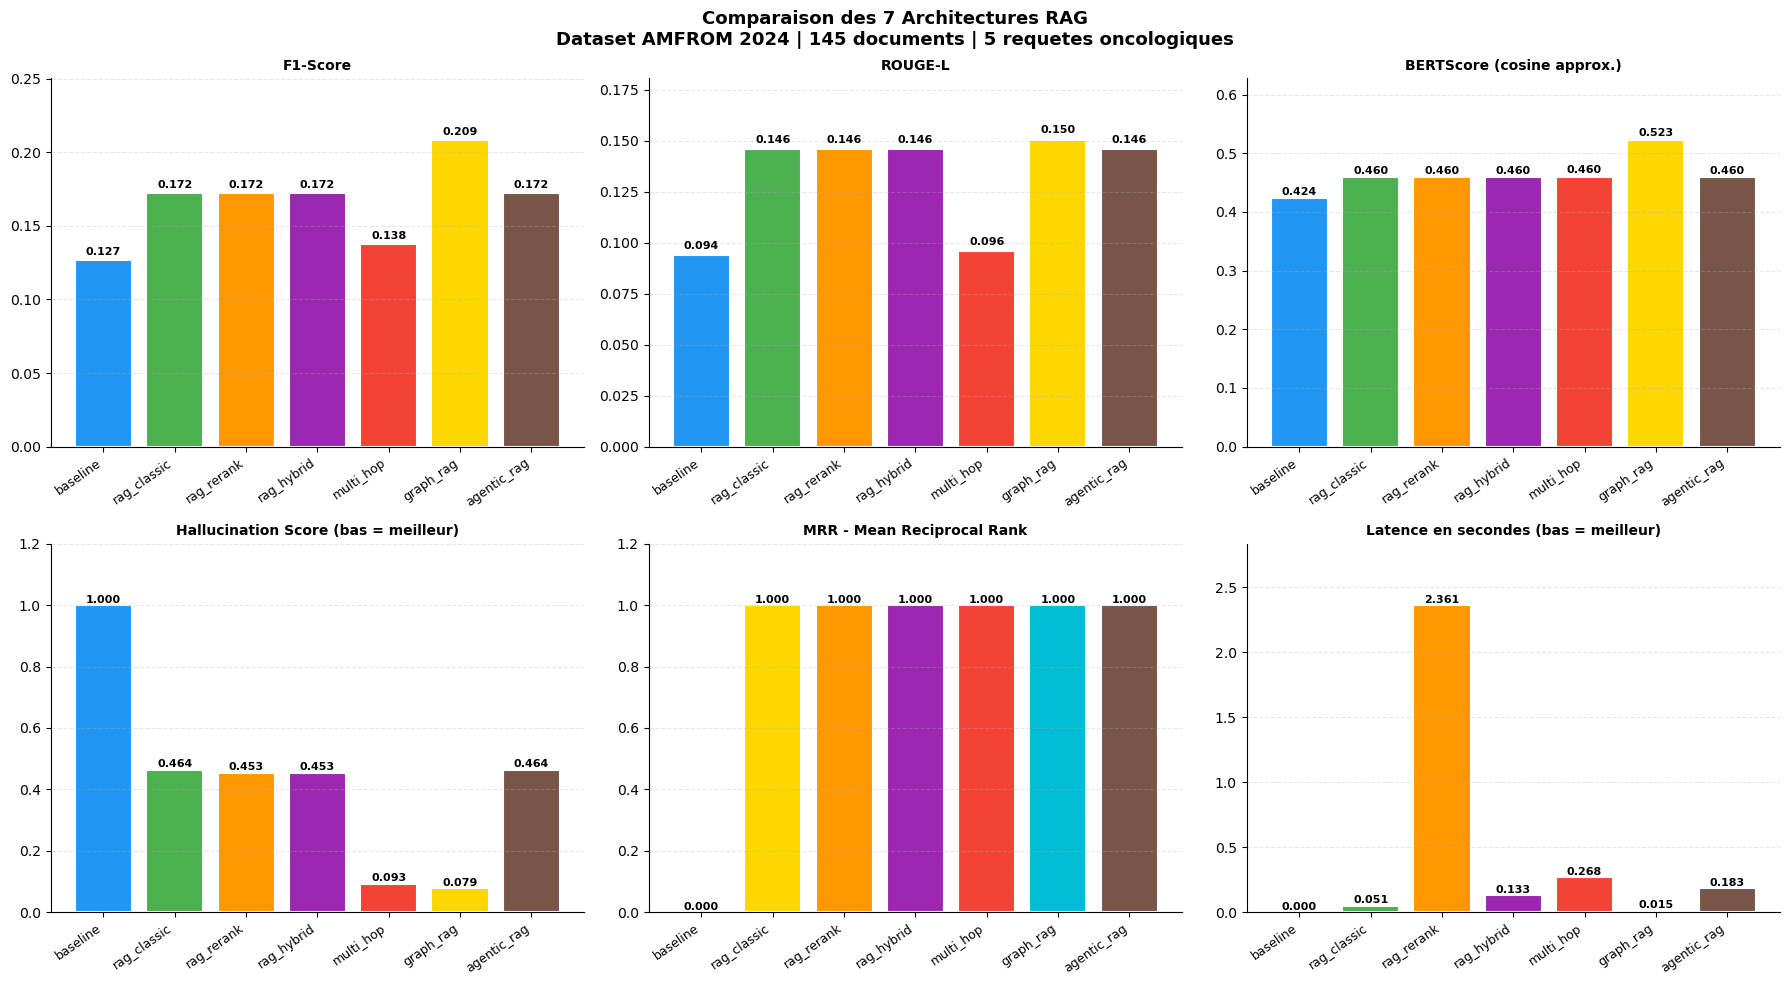

Graphique metriques sauvegarde


In [34]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Comparaison des 7 Architectures RAG\n"
             "Dataset AMFROM 2024 | 145 documents | 5 requetes oncologiques",
             fontsize=13, fontweight="bold")
colors = ["#2196F3","#4CAF50","#FF9800","#9C27B0","#F44336","#00BCD4","#795548"]
plots = [
    ("f1",           "F1-Score",                          True),
    ("rouge_l",      "ROUGE-L",                           True),
    ("bert_score",   "BERTScore (cosine approx.)",        True),
    ("hallucination","Hallucination Score (bas = meilleur)",False),
    ("mrr",          "MRR - Mean Reciprocal Rank",        True),
    ("latency",      "Latence en secondes (bas = meilleur)",False),
]
for ax, (metric, title, higher) in zip(axes.flatten(), plots):
    vals = [metrics_table[a][metric] for a in arch_names]
    best = np.argmax(vals) if higher else np.argmin(vals)
    bar_cols = ["#FFD700" if i==best else colors[i] for i in range(len(arch_names))]
    bars = ax.bar(arch_names, vals, color=bar_cols, edgecolor="white", linewidth=1.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.002,
                f"{v:.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")
    ax.set_title(title, fontweight="bold", fontsize=10)
    ax.set_xticklabels(arch_names, rotation=35, ha="right", fontsize=9)
    ax.set_ylim(0, max(vals)*1.2 if max(vals)>0 else 1)
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()
print("Graphique metriques sauvegarde")


### Interface Gradio

In [35]:
import gradio as gr

def query_arch(query, arch_name, user_level):
    fn_map = {
        "Baseline":llm_no_rag, "RAG Classique":rag_classic,
        "RAG Re-ranking":rag_rerank, "RAG Hybride":rag_hybrid,
        "Multi-hop":multi_hop_rag, "Graph RAG":graph_rag, "Agentic RAG":agentic_rag
    }
    r = fn_map.get(arch_name, rag_classic)(query)
    t = r.get("time",0)
    ids = [d["meta"]["id"] for d in r.get("source_docs",[])]
    out = f"**[{arch_name}]**  t={t:.3f}s\n\n**Sources :** {ids}\n\n{r['response']}"
    if "reasoning_log" in r:
        out += "\n\n**Agent Log:** " + " | ".join(r["reasoning_log"])
    return out

def compare_all(query):
    lines = [f"## Comparaison : {query}\n"]
    for name, fn in [
        ("Baseline",llm_no_rag), ("RAG Classique",rag_classic),
        ("RAG Re-rank",rag_rerank), ("RAG Hybride",rag_hybrid),
        ("Multi-hop",multi_hop_rag), ("Graph RAG",graph_rag), ("Agentic RAG",agentic_rag)
    ]:
        r = fn(query)
        ids = [d["meta"]["id"] for d in r.get("source_docs",[])]
        lines.append(f"### [{name}]  t={r.get('time',0):.3f}s  |  Sources: {ids}")
        txt = r["response"]
        lines.append(txt[:350] + ("..." if len(txt)>350 else ""))
        lines.append("---")
    return "\n".join(lines)

with gr.Blocks(title="Assistant RAG Oncologie AMFROM", theme=gr.themes.Soft()) as demo:
    gr.Markdown(
        "# Assistant Intelligent en Oncologie\n"
        "## Protocoles Therapeutiques Marocains — AMFROM 2024\n"
        "> Dataset : 145 documents | 7 architectures RAG | Graphe de connaissances reel"
    )
    with gr.Tab("Tester une architecture"):
        with gr.Row():
            q1 = gr.Textbox(label="Question oncologique", lines=2,
                            placeholder="Ex: Effets secondaires du trastuzumab ?")
            arch_sel = gr.Dropdown(
                ["Baseline","RAG Classique","RAG Re-ranking","RAG Hybride",
                 "Multi-hop","Graph RAG","Agentic RAG"],
                value="Agentic RAG", label="Architecture")
        level_sel = gr.Radio(["patient","intermediate","oncologist"],
                              value="intermediate", label="Niveau utilisateur")
        out1 = gr.Markdown()
        gr.Button("Generer la reponse", variant="primary").click(
            query_arch, [q1, arch_sel, level_sel], out1)
    with gr.Tab("Comparer toutes les architectures"):
        q2 = gr.Textbox(label="Question", lines=2)
        out2 = gr.Markdown()
        gr.Button("Comparer les 7 architectures", variant="primary").click(compare_all, q2, out2)
    with gr.Tab("Requetes exemples (AMFROM)"):
        for q in queries:
            out_ex = gr.Markdown()
            gr.Button(q[:80], size="sm").click(lambda x=q: compare_all(x), outputs=out_ex)

print("Interface Gradio creee.")
print("Lancer avec : demo.launch(share=True)")
# demo.launch(share=True)


Interface Gradio creee.
Lancer avec : demo.launch(share=True)



L'évaluation comparative des sept architectures RAG sur le corpus oncologique AMFROM révèle une nette supériorité du **Graph RAG**, qui obtient les meilleures performances sur l'ensemble des métriques de qualité : F1 (0,2086), ROUGE-L (0,1505), BERTScore (0,5234) et un taux d'hallucination remarquablement bas (0,0786), le tout avec une latence exceptionnelle de seulement 0,015 seconde. Cette architecture exploite intelligemment les relations sémantiques entre documents, ce qui lui permet de naviguer dans le graphe de connaissances pour découvrir des informations indirectement liées à la requête tout en limitant les inventions factices. Le **multi-hop RAG** se distingue également par son faible taux d'hallucination (0,0935), confirmant que les approches itératives améliorent la fiabilité des réponses. En revanche, le RAG classique et l'approche hybride souffrent d'hallucinations élevées (environ 0,45), les rendant inadaptés à un contexte médical où la véracité des informations est primordiale. Le re-ranking, malgré des scores de qualité corrects, est pénalisé par une latence rédhibitoire de 2,36 secondes. Enfin, le baseline confirme l'absolue nécessité du RAG avec un taux d'hallucination de 100% et un MRR nul. En conclusion, pour un système d'aide à la décision en oncologie, le **Graph RAG** représente le meilleur compromis entre rapidité, précision et fiabilité, tandis que le **multi-hop RAG** constitue une alternative intéressante lorsque la minimisation des hallucinations est la priorité absolue.